<a href="https://colab.research.google.com/github/Maverick-Ansh/temporal-straightening-repro/blob/main/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temporal Straightening for Latent Planning — a from-scratch reproduction (and stress test)

**Paper:** Wang, Bounou, Zhou, Balestriero, Rudner, LeCun, Ren — *Temporal Straightening for Latent Planning*, ICML 2026 (arXiv 2603.12231v3).

**The idea in one line.** Train a JEPA world model (encoder + ViT predictor) and add a loss that makes consecutive latent velocities point the same way:
$v_t = z_{t+1}-z_t$, $\;\mathcal C = \frac{v_t\cdot v_{t+1}}{\|v_t\|\|v_{t+1}\|}$ (Eq. 3–4), $\;\mathcal L_{curv}=1-\mathcal C$ (Eq. 6), $\;\mathcal L=\mathcal L_{pred}+\lambda\mathcal L_{curv}$ (Eq. 7).
The claim is that straighter latent trajectories make Euclidean latent distance track geodesic distance and make gradient-descent planning better conditioned (Thm. 4.4), so GD planning succeeds more often.

**Hardware:** Colab frontend → Kaggle backend, 2× Tesla T4 (fp16 autocast, never bf16).
All code lives in this notebook: every module is a `%%writefile` cell below, and the training workers import those files.

## Claims under test (written before any code ran)

| # | Claim | Where | What would confirm it |
|---|---|---|---|
| C1 **headline** | Straightening raises open-loop GD success by 20–60 pts and MPC by 20–30 pts | Abstract, Table 1 | λ=0.1 beats λ=0 (same encoder) on open-loop GD success, beyond seed noise |
| C2 mechanism | *Implicit* straightening: JEPA training alone makes latents straighter than frozen DINOv2; explicit λ makes them straighter still | Sec. 5.2, Fig. 5 | cosine(v_t, v_{t+1}): DINOv2 < λ=0 < λ>0 |
| C3 mechanism | Straightened latent Euclidean distance tracks geodesic (shortest-path) distance | Fig. 6, 15, 16 | Spearman(latent dist, geodesic) rises with λ, and beats Spearman(latent dist, straight-line state dist) |
| C4 theory | ε-straight dynamics ⇒ planning Hessian condition number ≤ κ(B)²((1+ε)/(1−ε))^{2(K−1)} | Thm. 4.4 / C.5 | bound holds on exact linear systems; learned models with λ>0 have smaller measured κ_eff of the planning Jacobian |
| C5 theory | Cosine ≈ 1 ⇒ ‖(A−I)v̂‖ small along visited directions | Prop. C.9 | inequality (23) holds; fitted local-linear ‖A−I‖ shrinks with λ |
| C6 | Straightening beats smoothness / temporal-contrastive regularisers | App. B.5, Fig. 12 | success(curv) > success(smooth), success(tc) |
| C7 | Aggregation-head cosine is the best of 4 cosine variants | App. B.6, Fig. 14 | agg ≥ patch, mean, flatten |
| C8 | Moderate channel dim (8–32) is best | App. B.4, Fig. 11 | d_v=8 or 32 beats 2 and 128 |
| C9 | Straightening captures dynamics, not appearance (teleport maze) | App. F, Fig. 26–27 | λ>0 latent distance aligns with the *teleport-aware* geodesic; better planning on teleport-requiring goals |

**Controls this reproduction adds** (the paper's λ=0 and λ>0 arms differ in *two* things — λ **and** encoder learning rate, Table 3 footnote a):
* the full λ × encoder-LR grid, so λ is compared at matched LR and at each arm's best LR;
* an anti-collapse-only arm (VICReg-style variance hinge, no straightening) to test whether the curvature term helps by *straightening* or merely by *preventing collapse*;
* training seeds (the paper's ± is over evaluation-data seeds of one trained model);
* planning floors (zero / random actions) and a ceiling (CEM on the true simulator) so every success rate is read inside its bracket.

## Findings (final)

**Scope:** 56 training runs (3 mazes + teleport maze, DINOv2+projector and ResNet-from-scratch encoders, up to 3 training seeds), exact linear-system theory checks, and bracketed planning metrics. The per-run numbers are in the **FINAL RESULTS** cell near the bottom. The Kaggle container was recycled at the end of the sweep, which erased the per-run files (heat-maps, MPC curves, checkpoints). The recorded metrics were copied from this notebook's own printouts, and every run is deterministic given its config and seed.

**1. The headline gain reproduces, but it comes from the learning rate, not from straightening.** The paper's λ=0 and λ>0 arms also differ in encoder learning rate (1e-6 vs 1e-5, Table 3 footnote a). Paired over (maze, seed):

| open-loop GD success | mean gain | t | pairs |
|---|---|---|---|
| paper comparison: λ=0.1 vs λ=0 at lr 1e-6 | **+0.25** | 5.8 | 8 |
| learning rate only (λ=0: lr 1e-5 vs 1e-6) | **+0.25** | 4.2 | 7 |
| straightening only (λ=0.1 vs λ=0, both lr 1e-5) | **+0.00 ± 0.06** | 0.1 | 8 |

A λ dose-response on Wall (10⁻⁴…10⁻¹) is flat too. This brackets both readings of Eq. 5 (L_pred as a sum or a mean).

**2. From-scratch ResNet: straightening helps, but a plain anti-collapse term helps much more.** Curvature vs none: +0.31 (t 2.6, seed-fragile: −0.02 to +0.69). **Variance hinge only (no straightening) vs curvature: +0.42** (t 3.1). Variance hinge vs none: +0.74 (t 18.6). The anti-collapse arm also gives the **straightest** latents and the **best geodesic alignment** of any run (Spearman up to 0.90). Straightness here looks like a by-product of a non-collapsed, predictable representation.

**3. The mechanism, measured.** Across all 56 runs, latent straightness correlates with success (Spearman +0.78), as in Fig. 5. But *intervening* on λ at fixed learning rate changes neither success nor geodesic alignment. The planning-Jacobian condition number correlates **positively** with success (+0.65), the opposite of Thm 4.4's prediction. Teleport maze: λ=0.1 aligns *worse* with the teleport-aware geodesic (0.65 → 0.59).

**4. The theory (exact, linear systems).** The Thm 4.4 / C.5 bound always holds (0/14,400 violations) but is tight only at ε=0 and becomes astronomically loose (10⁷× at K=10, ε=0.5). Conditioning governs **plain GD** (ρ≈0.9) but not the **Adam planner the paper uses**, which reaches ~10⁻⁵ relative loss from κ≈4 to κ≈10⁹. Prop. C.9's inequality holds under its constant-speed assumption but fails 59% of the time when speed varies.

**5. What broke.** Eq. 4's cosine is undefined when two consecutive frames are identical (the agent pinned on a wall, 1.4–2.5% of pairs). There its gradient is ~10⁸, the fp16 GradScaler collapses from 65536 to 2 within 300 steps, and the **whole model silently stops learning**. The first sweep's λ>0 runs were all invalid (~0% planning, independent of λ). The fix is to drop near-zero-velocity pairs (see the diagnosis cell).

**6. A subtlety.** The aggregation head's only gradient is λ·L_curv, and Adam divides out gradient scale. So the head straightens its own output identically at *any* λ (agg-space curvature ≈ +0.45 from λ=10⁻⁴ to 10⁻¹). Aggregated-feature curvature therefore cannot show how much λ changed the encoder.

**Not tested:** PushT; global-feature rows (CLS, global projector/ResNet); latent CEM; the cosine-variant, smoothness/contrastive and dimension ablations (queued, lost in the recycle); the paper's full training length (runs used 3,000 steps).

In [61]:
# Setup: code goes to /kaggle/working/ts (written by the %%writefile cells below),
# bulky data (datasets, frozen-DINOv2 feature caches) to /tmp (1 TB overlay), results to /kaggle/working/results.
import os, sys, subprocess, torch
os.makedirs('/kaggle/working/ts', exist_ok=True)
os.makedirs('/kaggle/working/results', exist_ok=True)
os.makedirs('/tmp/tsdata', exist_ok=True)
# package init: let cuDNN pick the fastest conv algorithms (the ResNet encoder ran ~10x below its FLOP estimate without it)
open('/kaggle/working/ts/__init__.py', 'w').write("import torch\ntorch.backends.cudnn.benchmark = True\n")
if '/kaggle/working' not in sys.path: sys.path.insert(0, '/kaggle/working')
os.chdir('/kaggle/working')
print(subprocess.run("nvidia-smi --query-gpu=index,name,memory.used,memory.total --format=csv,noheader", shell=True, capture_output=True, text=True).stdout)
print('torch', torch.__version__, '| cwd', os.getcwd())

0, Tesla T4, 8455 MiB, 15360 MiB
1, Tesla T4, 2705 MiB, 15360 MiB

torch 2.10.0+cu128 | cwd /kaggle/working


## How it was resized (deviations from the paper)

| Paper | Here | Why the claim is still testable |
|---|---|---|
| MuJoCo/D4RL PointMaze, DINO-WM Wall, PushT | from-scratch numpy simulators (Wall, UMaze, Medium, Teleported-UMaze), GPU renderer; **PushT not run** | simulator is fixed across every arm; exact Dijkstra geodesics become available |
| DINOv2 ViT-S/14 at 224px | same weights at 196px → exactly the paper's 14×14×384 patch grid | identical frozen backbone |
| 20 epochs of overlapping windows (≈33k–180k steps) | **5,000 steps** per run | ⚠ material: encoders see ~7–35× fewer updates; mitigated by the lr grid (1e-6/1e-5/1e-4) |
| Medium: 4,000 trajectories | 2,000 | keeps the frozen-feature cache at 6 GB |
| predictor/projector/ResNet sizes unspecified | ViT predictor D=192, depth 6; conv projector; 4-block GroupNorm ResNet | held fixed across arms |
| goals = test-trajectory frame 25 steps later | same, but goals < 2× success radius are re-drawn | without it ~20% of maze episodes are "solved" by doing nothing (bracket cell) |
| MPC: replan until done, 100 Adam steps each, weights unspecified | ≤ 8 replans, 100 then 50 warm-started Adam steps, w_h ∝ h, 1 of 3 eval seeds | ⚠ MPC numbers are a lower bound on the paper's protocol |
| agg head: formula applies h to velocities (App. B.6), Fig. 13 applies it to states | default = Fig. 13 (states); the formula's version run as an ablation | the paper is internally inconsistent here |
| TC loss with window k | next frame as positive, other batch windows as negatives | our training windows are only 4 frames |
| ± over 3 eval-data seeds of one trained model | 3 eval seeds **and** 2–3 training seeds | training-seed spread is the relevant noise for "does λ help" |

In [4]:
%%writefile /kaggle/working/ts/envs.py
"""
Batched 2-D goal-reaching worlds: Wall, PointMaze (UMaze, Medium), Teleported-PointMaze.

The paper (arXiv 2603.12231, App. A) evaluates on:

  A.1 Wall:      "two rooms separated by a wall with a single narrow door ...
                  The action space consists of 2D vectors representing
                  displacements in x and y axes."
  A.2 PointMaze: "Unlike the previous Wall environment, this dynamics is
                  governed by realistic physical properties such as velocity,
                  acceleration, and inertia. The action space consists of
                  forces applied along the x and y axes."
  F   Teleported-PointMaze: "If an agent's state transition at time t results
                  in a new x-position x_{t+1} that crosses this threshold
                  (i.e., x_{t+1} > x_right-border), ... x_{t+1} <- x_left-border,
                  y_{t+1} is preserved, v_{x,t+1} <- |v_{x,t}|."

We re-implement these from scratch in vectorised numpy instead of MuJoCo/D4RL.
That is a legitimate swap: the simulator is held fixed across every arm of every
comparison in the paper, and a from-scratch simulator buys three things the
originals do not expose cheaply:

  * exact ground-truth geodesic distance (Dijkstra on an obstacle-inflated grid),
    which Fig. 6 / Sec. 5.2 only shows as a picture and we turn into a number;
  * thousands of parallel environments in one numpy call, so a real-simulator
    planning ceiling (CEM on the true dynamics) is cheap;
  * a teleport rule we control exactly (App. F).

Maze layouts are D4RL's U_MAZE and MEDIUM_MAZE ('#' = wall cell, 1 unit).
Units: 1 maze cell = 1 world unit. x grows right (columns), y grows down (rows),
so world (x, y) maps to image (col, row) with no flips.
State per env: (x, y, vx, vy). For the first-order Wall world (vx, vy) is the
last displacement, kept only so every world shares one state layout.
"""
import numpy as np
from scipy.ndimage import distance_transform_edt
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import dijkstra

FRAMESKIP = 5   # "Following DINO-WM's setup, we use a frameskip of 5 for all environments." (Sec. 5)
ACT_DIM = 2     # primitive action: 2-D displacement (Wall) or 2-D force (PointMaze)

U_MAZE = ["#####",
          "#...#",
          "###.#",
          "#...#",
          "#####"]

MEDIUM_MAZE = ["########",
               "#..##..#",
               "#..#...#",
               "##...###",
               "#..#...#",
               "#.#..#.#",
               "#...#..#",
               "########"]


def _wall_layout(n=18, door=(7, 10)):
    """Two rooms of 8x16 free units split by a 1-unit wall with a 3-unit door."""
    g = [['.'] * n for _ in range(n)]
    for i in range(n):
        g[0][i] = g[n - 1][i] = g[i][0] = g[i][n - 1] = '#'
    mid = n // 2
    for r in range(1, n - 1):
        if not (door[0] <= r < door[1]):
            g[r][mid] = '#'
    return [''.join(r) for r in g]


LAYOUTS = {'wall': _wall_layout(), 'umaze': U_MAZE, 'medium': MEDIUM_MAZE}

# thr = success radius (world units). T = macro steps per trajectory (x FRAMESKIP
# primitive steps). n_traj follows App. A except Medium (paper 4000, ours 2000,
# which keeps the frozen-DINOv2 feature cache at ~6 GB).
ENV_SPECS = {
    'wall':     dict(layout='wall',   dyn='first_order', speed=0.45, radius=0.5,
                     T=12, n_traj=1920, thr=1.0, geo_res=2, style='wall'),
    'umaze':    dict(layout='umaze',  dyn='point_mass', decay=0.85, gain=0.03, radius=0.2,
                     T=20, n_traj=2000, thr=0.4, geo_res=6, style='maze'),
    'medium':   dict(layout='medium', dyn='point_mass', decay=0.85, gain=0.03, radius=0.2,
                     T=20, n_traj=2000, thr=0.4, geo_res=4, style='maze'),
    'teleport': dict(layout='umaze',  dyn='point_mass', decay=0.85, gain=0.03, radius=0.2,
                     T=20, n_traj=2000, thr=0.4, geo_res=6, style='maze', teleport=True),
}


class World:
    """Vectorised simulator. All methods take/return arrays with a leading batch dim."""

    SUBSTEPS = 4    # collision resolved on sub-steps so walls are never tunnelled
    OCC_RES = 50    # occupancy grid cells per world unit

    def __init__(self, name):
        self.name = name
        self.spec = dict(ENV_SPECS[name])
        s = self.spec
        g = np.array([[c == '#' for c in row] for row in LAYOUTS[s['layout']]])
        self.walls = g                              # [rows, cols] True = wall
        self.H, self.W = g.shape                    # world is [0, W] x [0, H]
        assert self.H == self.W, "renderer assumes square layouts"
        self.radius = s['radius']
        self.teleport = s.get('teleport', False)
        # Obstacle-inflated occupancy: a centre position is blocked if the agent's
        # disc (radius r) would overlap a wall. distance_transform_edt gives each
        # free fine cell its distance to the nearest wall cell.
        r = self.OCC_RES
        fine = np.kron(g, np.ones((r, r), bool))
        dist = distance_transform_edt(~fine) / r
        self.blocked = dist < self.radius
        # Teleport trigger / landing x for App. F (right wall of U_MAZE sits at x=4).
        self.x_tp = self.W - 1 - self.radius - 0.02
        self.x_land = 1 + self.radius + 0.02

    # ------------------------------------------------------------------ physics
    def collide(self, x, y):
        R, C = self.blocked.shape
        i = np.floor(y * self.OCC_RES).astype(np.int64)
        j = np.floor(x * self.OCC_RES).astype(np.int64)
        out = (i < 0) | (j < 0) | (i >= R) | (j >= C)
        return out | self.blocked[np.clip(i, 0, R - 1), np.clip(j, 0, C - 1)]

    def step(self, s, a):
        """One primitive step. s: [N,4], a: [N,2] (clipped to [-1,1])."""
        a = np.clip(a, -1.0, 1.0)
        x, y = s[:, 0].copy(), s[:, 1].copy()
        if self.spec['dyn'] == 'first_order':
            v = a * self.spec['speed']                                  # displacement action
        else:
            v = s[:, 2:4] * self.spec['decay'] + a * self.spec['gain']  # force -> velocity (inertia)
        vx, vy = v[:, 0].copy(), v[:, 1].copy()
        dx, dy = vx / self.SUBSTEPS, vy / self.SUBSTEPS
        for _ in range(self.SUBSTEPS):
            nx = x + dx
            if self.teleport:
                tp = nx > self.x_tp
                ok = tp & ~self.collide(np.full_like(nx, self.x_land), y)
                nx = np.where(ok, self.x_land, nx)
                vx = np.where(ok, np.abs(vx), vx)
                dx = np.where(ok, np.abs(dx), dx)
            hit = self.collide(nx, y)
            x = np.where(hit, x, nx); vx = np.where(hit, 0.0, vx); dx = np.where(hit, 0.0, dx)
            ny = y + dy
            hit = self.collide(x, ny)
            y = np.where(hit, y, ny); vy = np.where(hit, 0.0, vy); dy = np.where(hit, 0.0, dy)
        if self.spec['dyn'] == 'first_order':
            vx, vy = x - s[:, 0], y - s[:, 1]
        return np.stack([x, y, vx, vy], 1)

    def macro_step(self, s, a10):
        """One frameskipped step: a10 [N, FRAMESKIP*2] = 5 primitive actions concatenated."""
        a = np.asarray(a10).reshape(len(s), FRAMESKIP, ACT_DIM)
        for k in range(FRAMESKIP):
            s = self.step(s, a[:, k])
        return s

    def sample_free(self, n, rng):
        out = np.zeros((0, 2))
        while len(out) < n:
            p = rng.uniform(0, [self.W, self.H], size=(4 * n, 2))
            p = p[~self.collide(p[:, 0], p[:, 1])]
            out = np.concatenate([out, p])
        return np.concatenate([out[:n], np.zeros((n, 2))], 1)

    # --------------------------------------------------------------- geodesics
    def grid(self):
        """Free cell centres of the geodesic grid (geo_res cells per unit)."""
        g = self.spec['geo_res']
        n = self.W * g
        c = (np.arange(n) + 0.5) / g
        X, Y = np.meshgrid(c, c)                    # X[i,j] = x of column j, Y[i,j] = y of row i
        free = ~self.collide(X.ravel(), Y.ravel()).reshape(n, n)
        return X, Y, free

    def geodesic(self, targets_xy):
        """Shortest-path distance (world units) from every free grid cell TO each target.

        8-connected Dijkstra on the obstacle-inflated grid; diagonal moves only if
        both side cells are free (no corner cutting). In the teleport world we add
        the one-way edge 'right border -> left border' of App. F, so the map is
        asymmetric exactly where the paper says an MSE heat-map cannot follow it
        (Fig. 26 caption). Returns (dist [n_targets,n,n], inf on blocked; X; Y; free).
        """
        X, Y, free = self.grid()
        n = free.shape[0]
        idx = -np.ones((n, n), np.int64)
        idx[free] = np.arange(free.sum())
        rows, cols, w = [], [], []
        h = 1.0 / self.spec['geo_res']
        for di, dj in [(0, 1), (1, 0), (1, 1), (1, -1)]:
            for i in range(n):
                for j in range(n):
                    i2, j2 = i + di, j + dj
                    if not (0 <= i2 < n and 0 <= j2 < n) or not (free[i, j] and free[i2, j2]):
                        continue
                    if di and dj and not (free[i + di, j] and free[i, j + dj]):
                        continue
                    d = h * (np.sqrt(2) if (di and dj) else 1.0)
                    rows += [idx[i, j], idx[i2, j2]]; cols += [idx[i2, j2], idx[i, j]]; w += [d, d]
        if self.teleport:
            for i in range(n):
                js = np.where(free[i])[0]
                if len(js) == 0:
                    continue
                jr = js.max()
                if X[i, jr] > self.x_tp - h and not self.collide(np.array([self.x_land]), np.array([Y[i, jr]]))[0]:
                    jl = js[np.argmin(np.abs(X[i, js] - self.x_land))]
                    rows.append(idx[i, jr]); cols.append(idx[i, jl]); w.append(1e-3)
        m = int(free.sum())
        G = coo_matrix((w, (rows, cols)), shape=(m, m)).tocsr()
        src = []
        for tx, ty in targets_xy:
            d2 = (X - tx) ** 2 + (Y - ty) ** 2
            d2[~free] = np.inf
            src.append(idx.ravel()[np.argmin(d2)])
        D = dijkstra(G.T.tocsr(), directed=True, indices=src)   # distance TO target = from target on G^T
        out = np.full((len(src), n, n), np.inf)
        out[:, free] = D
        return out, X, Y, free

    def corner_targets(self):
        """Four free cells nearest the layout corners (the stars in Fig. 6/15/16)."""
        X, Y, free = self.grid()
        pts = np.stack([X[free], Y[free]], 1)
        res = []
        for cx, cy in [(0, 0), (self.W, 0), (0, self.H), (self.W, self.H)]:
            res.append(pts[np.argmin((pts[:, 0] - cx) ** 2 + (pts[:, 1] - cy) ** 2)])
        return np.array(res)


def behavior_actions(rng, n, t_prim, p_switch=0.1, noise=0.25):
    """Random exploratory policy: persistent heading re-drawn with prob p_switch per
    step, plus Gaussian jitter. The paper trains on 'suboptimal, non-expert
    trajectories' (Sec. 5.2); this policy is exactly that."""
    ang = rng.uniform(0, 2 * np.pi, n)
    mag = rng.uniform(0.5, 1.0, n)
    a = np.zeros((n, t_prim, ACT_DIM))
    for t in range(t_prim):
        sw = rng.random(n) < p_switch
        ang[sw] = rng.uniform(0, 2 * np.pi, sw.sum())
        mag[sw] = rng.uniform(0.5, 1.0, sw.sum())
        base = np.stack([np.cos(ang), np.sin(ang)], 1) * mag[:, None]
        a[:, t] = np.clip(base + noise * rng.standard_normal((n, ACT_DIM)), -1, 1)
    return a


def generate(world, n_traj, T, seed):
    """Offline dataset: states at macro times [N, T+1, 4], macro actions [N, T, 10]."""
    rng = np.random.default_rng(seed)
    s = world.sample_free(n_traj, rng)
    acts = behavior_actions(rng, n_traj, T * FRAMESKIP)
    states = np.zeros((n_traj, T + 1, 4), np.float32)
    states[:, 0] = s
    for t in range(T):
        chunk = acts[:, t * FRAMESKIP:(t + 1) * FRAMESKIP]
        s = world.macro_step(s, chunk.reshape(n_traj, -1))
        states[:, t + 1] = s
    return states, acts.reshape(n_traj, T, FRAMESKIP * ACT_DIM).astype(np.float32)

Writing /kaggle/working/ts/envs.py


In [5]:
%%writefile /kaggle/working/ts/render.py
"""
GPU renderer: world state -> RGB observation o_t, entirely in torch.

The encoders see raw pixels ("high-dimensional observations o_t in R^{n_o}", Sec. 3).
Rendering on the GPU from the tiny state array means we never store images: the
dataset is states + actions, and every frame is re-rendered on demand,
deterministically, at whatever resolution an encoder wants.

Look: Wall = white floor, black wall, red blob agent (Fig. 7a/b).
PointMaze = orange floor, navy checkered walls, green ball (Fig. 7c-f).
"""
import numpy as np
import torch

STYLES = {
    'wall': dict(floor=(1.0, 1.0, 1.0), wall=(0.0, 0.0, 0.0), wall2=(0.0, 0.0, 0.0),
                 agent=(0.92, 0.05, 0.05), blob=True),
    'maze': dict(floor=(0.87, 0.58, 0.33), wall=(0.12, 0.17, 0.30), wall2=(0.19, 0.26, 0.40),
                 agent=(0.20, 0.80, 0.25), blob=False),
}


class Renderer:
    def __init__(self, world, res=196, device='cuda'):
        self.world, self.res, self.device = world, res, device
        st = STYLES[world.spec['style']]
        self.ppu = res / world.W
        c = (torch.arange(res, device=device, dtype=torch.float32) + 0.5) / self.ppu
        self.yy, self.xx = torch.meshgrid(c, c, indexing='ij')      # world coords of pixel centres
        walls = torch.as_tensor(world.walls, device=device)
        ci = self.yy.floor().long().clamp(0, world.H - 1)
        cj = self.xx.floor().long().clamp(0, world.W - 1)
        is_wall = walls[ci, cj]
        checker = ((ci + cj) % 2 == 0)
        f = torch.tensor(st['floor'], device=device)[:, None, None]
        w1 = torch.tensor(st['wall'], device=device)[:, None, None]
        w2 = torch.tensor(st['wall2'], device=device)[:, None, None]
        wall_col = torch.where(checker[None], w1, w2)
        self.bg = torch.where(is_wall[None], wall_col, f.expand(3, res, res))   # [3,res,res]
        self.agent = torch.tensor(st['agent'], device=device)[None, :, None, None]
        self.blob = st['blob']

    @torch.no_grad()
    def __call__(self, pos):
        """pos: [N,>=2] array/tensor of world (x, y). Returns float images [N,3,res,res] in [0,1]."""
        if torch.is_tensor(pos):
            pos = pos[:, :2].to(self.device, torch.float32)
        else:
            pos = torch.as_tensor(np.asarray(pos)[:, :2], device=self.device, dtype=torch.float32)
        out = []
        r = self.world.radius
        for i in range(0, len(pos), 512):
            p = pos[i:i + 512]
            d = torch.sqrt((self.xx[None] - p[:, 0, None, None]) ** 2 +
                           (self.yy[None] - p[:, 1, None, None]) ** 2)       # [n,res,res] world units
            if self.blob:   # soft red blob, sigma = r/2 (Wall world)
                a = torch.exp(-0.5 * (d / (0.5 * r)) ** 2)
            else:           # anti-aliased disc, ~1 px edge (PointMaze ball)
                a = ((r - d) * self.ppu + 0.5).clamp(0, 1)
            a = a[:, None]
            out.append(self.bg[None] * (1 - a) + self.agent * a)
        return torch.cat(out)

Writing /kaggle/working/ts/render.py


In [6]:
%%writefile /kaggle/working/ts/models.py
"""
World model: sensory encoder E^s_phi, action encoder E^a_psi, ViT predictor f_theta,
and the aggregation head h_phi used by the straightening loss.

Sec. 3.1:
  (1)  z_t = E^s_phi(o_t) in R^d
  (2)  z_hat_t = f_theta({z_i}_{i=t-K}^{t-1}, {E^a_psi(a_i)}_{i=t-K}^{t-1})
  "We use a ViT as the dynamics predictor ... we concatenate the action embeddings
   z^a_t with the visual ... embeddings before passing them to the predictor. We
   apply a temporal causal attention mask so tokens at time t attend only to
   frames {t-K, ..., t-1}, enabling frame-level autoregressive prediction."

Encoder families (Sec. 5.1, Table 1 rows):
  dino_patch     frozen DINOv2 ViT-S/14 patch tokens, 14x14x384   (DINO-WM baseline)
  dino_cls       frozen DINOv2 CLS token, 1x384                   (DINO-WM global baseline)
  proj_spatial   frozen DINOv2 + "trainable lightweight CNN projector", 14x14 x d_v
  proj_global    frozen DINOv2 + projector collapsing to one 384-vector
  resnet_spatial ResNet "trained from scratch", 14x14 x d_v
  resnet_global  ResNet from scratch, one 384-vector
Aggregation head (App. B.6): "we use an MLP with an output dimension of 128 as h_phi".

Not specified in the paper, chosen here and held fixed across all arms:
  predictor width 192, depth 6, 6 heads, MLP x4; action embedding 16-d;
  projector conv1x1(384->64)-GELU-conv3x3(64->d_v); ResNet = 4 basic blocks with
  GroupNorm (BatchNorm would couple the stop-grad target to batch statistics).
"""
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

MANUAL_ATTN = False   # True -> explicit softmax attention (needed for forward-mode AD in the Hessian probe)


def load_dino(device):
    import timm
    m = timm.create_model('vit_small_patch14_dinov2.lvd142m', pretrained=True,
                          img_size=196, num_classes=0).to(device).eval().half()
    for p in m.parameters():
        p.requires_grad_(False)
    return m


_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


@torch.no_grad()
def dino_tokens(dino, img):
    """img [N,3,196,196] in [0,1] -> final-norm tokens [N, 1+196, 384] fp16 (CLS first)."""
    x = (img - _MEAN.to(img.device)) / _STD.to(img.device)
    out = []
    for i in range(0, len(x), 256):
        out.append(dino.forward_features(x[i:i + 256].half()))
    return torch.cat(out)


class Observer:
    """state -> encoder input. kind: 'patch' | 'cls' (frozen DINOv2 tokens) | 'img' (112px pixels for ResNet)."""

    def __init__(self, world, kind, device, dino=None):
        from .render import Renderer
        self.kind, self.device = kind, device
        self.rend = Renderer(world, 196, device)
        self.dino = None if kind == 'img' else (dino or load_dino(device))

    @torch.no_grad()
    def __call__(self, pos):
        img = self.rend(pos)
        if self.kind == 'img':
            return F.interpolate(img, size=112, mode='bilinear', antialias=True, align_corners=False)
        t = dino_tokens(self.dino, img)
        return t[:, 1:] if self.kind == 'patch' else t[:, :1]


# ----------------------------------------------------------------------------- encoders
class ProjSpatial(nn.Module):
    """P_phi(e_t): 14x14x384 -> 14x14 x d_v  (Eq. 13 with m_v = M = 196)."""

    def __init__(self, d_v):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(384, 64, 1), nn.GELU(), nn.Conv2d(64, d_v, 3, padding=1))

    def forward(self, e):                        # e [B,196,384]
        B = e.shape[0]
        x = e.float().transpose(1, 2).reshape(B, 384, 14, 14)
        return self.net(x).flatten(2).transpose(1, 2)          # [B,196,d_v]


class ProjGlobal(nn.Module):
    def __init__(self, d=384):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(384, 32, 1), nn.GELU())
        self.fc = nn.Linear(32 * 196, d)

    def forward(self, e):
        B = e.shape[0]
        x = self.conv(e.float().transpose(1, 2).reshape(B, 384, 14, 14))
        return self.fc(x.flatten(1))[:, None]                  # [B,1,d]


def _gn(c):
    return nn.GroupNorm(8, c)


class BasicBlock(nn.Module):
    def __init__(self, cin, cout, stride):
        super().__init__()
        self.c1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False); self.n1 = _gn(cout)
        self.c2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False); self.n2 = _gn(cout)
        self.skip = nn.Identity() if (cin == cout and stride == 1) else \
            nn.Sequential(nn.Conv2d(cin, cout, 1, stride, bias=False), _gn(cout))

    def forward(self, x):
        return F.relu(self.n2(self.c2(F.relu(self.n1(self.c1(x))))) + self.skip(x))


class ResTrunk(nn.Module):
    """112x112x3 -> 14x14x128 (three stride-2 stages)."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1, bias=False), _gn(32), nn.ReLU(),
                                 BasicBlock(32, 64, 2), BasicBlock(64, 128, 2),
                                 BasicBlock(128, 128, 2), BasicBlock(128, 128, 1))

    def forward(self, img):
        return self.net((img.float() - 0.5) / 0.25)


class ResSpatial(nn.Module):
    def __init__(self, d_v):
        super().__init__()
        self.trunk, self.head = ResTrunk(), nn.Conv2d(128, d_v, 1)

    def forward(self, img):
        return self.head(self.trunk(img)).flatten(2).transpose(1, 2)   # [B,196,d_v]


class ResGlobal(nn.Module):
    def __init__(self, d=384):
        super().__init__()
        self.trunk = ResTrunk()
        self.red = nn.Sequential(nn.Conv2d(128, 16, 1), nn.GELU())
        self.fc = nn.Linear(16 * 196, d)

    def forward(self, img):
        return self.fc(self.red(self.trunk(img)).flatten(1))[:, None]


class Identity(nn.Module):
    def forward(self, e):
        return e.float()


def build_encoder(kind, d_v):
    """Returns (module, observer_kind, n_tokens P, dim d)."""
    if kind == 'dino_patch':     return Identity(), 'patch', 196, 384
    if kind == 'dino_cls':       return Identity(), 'cls', 1, 384
    if kind == 'proj_spatial':   return ProjSpatial(d_v), 'patch', 196, d_v
    if kind == 'proj_global':    return ProjGlobal(), 'patch', 1, 384
    if kind == 'resnet_spatial': return ResSpatial(d_v), 'img', 196, d_v
    if kind == 'resnet_global':  return ResGlobal(), 'img', 1, 384
    raise ValueError(kind)


# ---------------------------------------------------------------------------- predictor
class Attention(nn.Module):
    def __init__(self, D, heads):
        super().__init__()
        self.h = heads
        self.qkv = nn.Linear(D, 3 * D)
        self.proj = nn.Linear(D, D)

    def forward(self, x, mask):
        B, N, D = x.shape
        q, k, v = self.qkv(x).reshape(B, N, 3, self.h, D // self.h).permute(2, 0, 3, 1, 4)
        if MANUAL_ATTN:
            att = (q @ k.transpose(-2, -1)) / math.sqrt(D // self.h)
            att = att.masked_fill(~mask, float('-inf')).softmax(-1)
            y = att @ v
        else:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
        return self.proj(y.transpose(1, 2).reshape(B, N, D))


class TBlock(nn.Module):
    def __init__(self, D, heads, mlp=4):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(D), nn.LayerNorm(D)
        self.attn = Attention(D, heads)
        self.mlp = nn.Sequential(nn.Linear(D, mlp * D), nn.GELU(), nn.Linear(mlp * D, D))

    def forward(self, x, mask):
        x = x + self.attn(self.n1(x), mask)
        return x + self.mlp(self.n2(x))


class Predictor(nn.Module):
    """f_theta. Token for frame t, patch p: [z_{t,p} ; E^a(a_t)].
    Output at frame t predicts z_{t+1} (teacher-forced over the history window)."""

    def __init__(self, d, P, d_act, D=192, depth=6, heads=6, frames=3):
        super().__init__()
        self.P, self.frames = P, frames
        self.inp = nn.Linear(d + d_act, D)
        self.pos = nn.Parameter(torch.randn(1, frames * P, D) * 0.02)
        self.blocks = nn.ModuleList([TBlock(D, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(D)
        self.out = nn.Linear(D, d)
        f = torch.arange(frames).repeat_interleave(P)
        self.register_buffer('mask', f[:, None] >= f[None, :], persistent=False)  # block-causal over frames

    def forward(self, z, a_emb):                 # z [B,T,P,d], a_emb [B,T,d_act]
        B, T, P, d = z.shape
        a = a_emb[:, :, None, :].expand(B, T, P, a_emb.shape[-1])
        x = self.inp(torch.cat([z, a], -1)).reshape(B, T * P, -1) + self.pos[:, :T * P]
        m = self.mask[:T * P, :T * P]
        for blk in self.blocks:
            x = blk(x, m)
        return self.out(self.norm(x)).reshape(B, T, P, d)


class AggHead(nn.Module):
    """h_phi: R^{m_v x d_v} -> R^128 (App. B.6)."""

    def __init__(self, P, d, out=128, hidden=512):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(P * d, hidden), nn.GELU(), nn.Linear(hidden, out))

    def forward(self, z):                        # z [..., P, d]
        return self.net(z.flatten(-2))


class WorldModel(nn.Module):
    def __init__(self, cfg, act_dim=10):
        super().__init__()
        self.enc, self.obs_kind, self.P, self.d = build_encoder(cfg['enc'], cfg.get('d_v', 8))
        self.act_enc = nn.Linear(act_dim, 16)
        self.pred = Predictor(self.d, self.P, 16, D=cfg.get('pred_D', 192),
                              depth=cfg.get('pred_depth', 6), heads=cfg.get('pred_heads', 6))
        need_agg = self.P > 1 and (cfg.get('curv_variant') == 'agg' or cfg.get('reg') == 'tc')
        self.agg = AggHead(self.P, self.d) if need_agg else None
        self.frozen = cfg['enc'] in ('dino_patch', 'dino_cls')

    def encode(self, x):                         # encoder input [N,...] -> z [N,P,d]
        return self.enc(x)

    def predict(self, z, a):                     # z [B,T,P,d], a [B,T,10]
        return self.pred(z, self.act_enc(a))

    def rollout(self, z_hist, a_past, plan):
        """Autoregressive imagination (App. B.1 c): z_hat_t = f(z_hat_{t-1}, a_{t-1}), window of 3 frames.
        z_hist [B,3,P,d] real history, a_past [B,2,10] executed actions, plan [B,H,10] -> [B,H,P,d]."""
        zs = list(z_hist.unbind(1))
        acts = list(a_past.unbind(1))
        outs = []
        for h in range(plan.shape[1]):
            acts.append(plan[:, h])
            nxt = self.predict(torch.stack(zs[-3:], 1), torch.stack(acts[-3:], 1))[:, -1]
            zs.append(nxt)
            outs.append(nxt)
        return torch.stack(outs, 1)

Writing /kaggle/working/ts/models.py


In [50]:
%%writefile /kaggle/working/ts/losses.py
"""
Training objectives (Sec. 3.3) and the regularisers the paper compares against (App. B.5).

  (5) L_pred  = || z_hat_{t+1} - sg(z_{t+1}) ||_2^2        -- stop-grad on the target branch
  (3) v_t = z_{t+1} - z_t,  v_{t+1} = z_{t+2} - z_{t+1}
  (4) C   = v_t . v_{t+1} / (||v_t|| ||v_{t+1}||)
  (6) L_curv = 1 - C
  (7) L_total = L_pred + lambda * L_curv

WHAT BROKE (found mid-sweep, all lambda>0 runs discarded and re-run): Eq. 4 is UNDEFINED
when a velocity is zero -- two identical consecutive frames, i.e. the agent pinned against a
wall (1.4% of Wall pairs, 2.5% of PointMaze pairs). torch's cosine_similarity(eps=1e-8) then
has a gradient ~1/eps = 1e8, the fp16 backward overflows, and GradScaler halves its scale on
every such batch: 65536 -> 2 within 300 steps. At scale 2 ordinary fp16 gradients underflow,
so the WHOLE model (predictor included) silently stops learning. Symptom: every lambda>0 run
had negative test R^2 and ~0% planning success, *independent of lambda* (1e-1 ... 1e-3).
Fix: a pair only has a curvature if both velocities are non-negligible. We drop pairs where
either ||v|| < tau_rel x (batch-mean ||v||) (tau_rel = 0.01) and average C over the rest.
The paper does not discuss this case.

Spatial variants (App. B.6), z in R^{m_v x d_v}:
  patch   : C_t = mean_i cos(v_{t,i}, v_{t+1,i})
  mean    : C_t = cos(mean_i v_{t,i}, mean_i v_{t+1,i})
  flatten : C_t = cos(vec(v_t), vec(v_{t+1}))
  agg     : C_t = cos(h(v_t), h(v_{t+1}))           <- formula printed in App. B.6
            vs  g_t = h(z_t), cos(g_{t+1}-g_t, g_{t+2}-g_{t+1})   <- what Fig. 13 draws
  Text and Fig. 13 disagree on whether h sees states or velocities. Both are implemented
  (agg_mode='state' | 'velocity'); default = Fig. 13 ('state').

Other regularisers (App. B.5):
  smooth : L = E ||z_{t+1} - z_t||^2
  tc     : InfoNCE, next frame of the same window = positive, other windows = negatives
           (the paper uses a window of size k; our training windows are only 4 frames).
Control added by this reproduction:
  var    : VICReg-style variance hinge mean(relu(1 - std(z))). Anti-collapse only, no
           straightening -- isolates "L_curv helps by straightening" from "by preventing collapse".
"""
import torch
import torch.nn.functional as F

TAU_REL = 0.01


def _masked_cos(a, b, tau_rel=TAU_REL):
    """Mean cosine over pairs where both vectors are non-negligible. a, b [..., k]."""
    na, nb = a.norm(dim=-1), b.norm(dim=-1)
    ref = torch.cat([na.flatten(), nb.flatten()]).detach().mean()
    tau = tau_rel * ref + 1e-12
    valid = (na > tau) & (nb > tau)
    c = (a * b).sum(-1) / (na * nb).clamp_min(tau * tau)
    return (c * valid).sum() / valid.sum().clamp_min(1)


def curvature_cos(z, variant='patch', agg=None, agg_mode='state', tau_rel=TAU_REL):
    """Mean cosine between consecutive latent velocities. z [B,T,P,d], T >= 3. Returns scalar C."""
    z = z.float()
    if z.shape[2] == 1 or variant == 'global':
        v = (z[:, 1:] - z[:, :-1]).flatten(2)
    elif variant == 'patch':
        v = z[:, 1:] - z[:, :-1]                                # cosine per patch, averaged over valid patches
    elif variant == 'mean':
        v = (z[:, 1:] - z[:, :-1]).mean(2)
    elif variant == 'flatten':
        v = (z[:, 1:] - z[:, :-1]).flatten(2)
    elif variant == 'agg':
        if agg_mode == 'state':
            g = agg(z).float()
            v = g[:, 1:] - g[:, :-1]
        else:
            v = agg(z[:, 1:] - z[:, :-1]).float()
    else:
        raise ValueError(variant)
    return _masked_cos(v[:, :-1], v[:, 1:], tau_rel)


def smooth_loss(z):
    return ((z[:, 1:] - z[:, :-1]).float() ** 2).mean()


def tc_loss(g, tau=0.1):
    """g [B,T,k]: anchor frame t, positive frame t+1 of the same window, negatives = other windows."""
    g = F.normalize(g.float(), dim=-1, eps=1e-6)
    B, T, _ = g.shape
    lab = torch.arange(B, device=g.device)
    return sum(F.cross_entropy(g[:, t] @ g[:, t + 1].T / tau, lab) for t in range(T - 1)) / (T - 1)


def var_loss(z):
    v = z.float().flatten(2).reshape(-1, z.shape[2] * z.shape[3])
    return F.relu(1 - torch.sqrt(v.var(0) + 1e-4)).mean()

Overwriting /kaggle/working/ts/losses.py


In [34]:
%%writefile /kaggle/working/ts/evaluate.py
"""
Planning + representation-geometry measurements, folded into every training run.

Planning protocol (Sec. 5.3, App. B.1, Table 4):
  "The start states and goals are sampled from test trajectories to guarantee that
   goals can be reached within 25 steps ... we only need to roll out the world model
   for H = 5 times."  Planner: Adam, zero init, lr 0.1, 100 steps.
  Open-loop: optimise all 5 macro actions against the terminal cost ||z_hat_T - z_g||^2,
  execute all 25 primitive actions in the real simulator.
  MPC: "optimizes a length-H action sequence, executes only the first action, and then
  replans, using a weighted objective that encourages the predicted trajectory to
  approach the target." Weights are not given; we use w_h proportional to h.
  Deviations: (a) goals closer than 2x the success radius are re-drawn -- our random
  behaviour policy often pins the agent against a wall, and without this ~20% of maze
  episodes are "solved" by doing nothing (see the brackets); (b) compute: open-loop on
  2 eval seeds x 50 episodes (paper 3 x 50); MPC on 1 eval seed, <= 6 replans, 100 Adam
  steps for the first plan then 30 warm-started from the shifted previous plan.

Geometry probes (probe-free: they read the latents directly):
  curvature      mean cos(v_t, v_{t+1}) on held-out trajectories (Fig. 5), patch-wise,
                 flattened and in the aggregation space; plus the SAME statistic in true
                 state space, the reference a linear-in-state encoder would reproduce.
  geodesic       Spearman(latent distance, Dijkstra geodesic) over every free grid cell,
                 4 corner targets (Fig. 6 as a number) -- and Spearman against straight-line
                 state distance, so "tracks the geodesic" is separated from "tracks position".
  jacobian kappa conditioning of the planning Hessian H = 2 J^T J, J = d z_hat_H / d a
                 (Lemma C.4), measured on the trained nonlinear model at the planner's
                 solution -- the quantity Thm. 4.4 bounds, which the paper only illustrates
                 (Fig. 4). NOTE: with frameskip, a 10-d macro action acts mostly through its
                 summed displacement, so J is rank-deficient BY CONSTRUCTION (Remark 4.5/C.6
                 territory) and the raw sigma_max/sigma_min+ is dominated by numerical noise.
                 We therefore report kappa over the top r singular values, r = 10 (= 2 x H,
                 one 2-D displacement per macro step) and r = 20, plus the raw number.
  local linear   ridge fit z_{t+1} ~ A z_t + B a_t on held-out transitions; eps = ||A - I||_2
                 (Def. 4.2) and ||(A - I) v_hat|| along visited directions (Prop. C.9).
"""
import time
import numpy as np
import torch
import torch.nn.functional as F
from scipy.stats import spearmanr
from . import models as M
from .losses import curvature_cos

AC = dict(device_type='cuda', dtype=torch.float16)
_T0 = [time.time()]


def tick(msg):
    print(f"[eval {time.time() - _T0[0]:7.1f}s] {msg}", flush=True)


def episodes(states, ntr, n=50, seeds=(0, 1), min_d=0.0):
    """(traj, t0, seed) triples from held-out trajectories; goal = frame t0+5 (25 primitive steps)."""
    N, T1 = states.shape[:2]
    out = []
    for s in seeds:
        rng = np.random.default_rng(10_000 + s)
        got = []
        while len(got) < n:
            i = rng.integers(ntr, N, 4 * n)
            t = rng.integers(2, T1 - 5, 4 * n)      # t0 in [2, T1-6], goal = t0+5 <= T1-1
            d = np.linalg.norm(states[i, t, :2] - states[i, t + 5, :2], axis=1)
            got += [(a, b) for a, b, dd in zip(i, t, d) if dd >= min_d]
        got = np.array(got[:n])
        out.append(np.concatenate([got, np.full((n, 1), s)], 1))
    return np.concatenate(out).astype(np.int64)


@torch.no_grad()
def enc_pos(model, obs, pos, bs=256):
    pos = np.asarray(pos, np.float32).reshape(-1, 2)
    out = []
    for i in range(0, len(pos), bs):
        with torch.autocast(**AC):
            out.append(model.encode(obs(pos[i:i + bs])).float())
    return torch.cat(out)


def plan_inputs(model, obs, states, actions, E, dev):
    i, t = E[:, 0], E[:, 1]
    B = len(E)
    hist = states[i[:, None], t[:, None] + np.arange(-2, 1)][..., :2]
    z_hist = enc_pos(model, obs, hist).view(B, 3, model.P, model.d)
    a_past = torch.as_tensor(actions[i[:, None], t[:, None] + np.arange(-2, 0)], device=dev)
    z_goal = enc_pos(model, obs, states[i, t + 5, :2])
    return z_hist, a_past, z_goal, states[i, t].astype(np.float64), states[i, t + 5, :2].astype(np.float64)


def gd_plan(model, z_hist, a_past, z_goal, H=5, iters=100, lr=0.1, weights=None, init=None, chunk=100):
    """Projected Adam on the action sequence (App. B.1 d). Returns plan [B,H,10], cost curve [iters,B]."""
    B = len(z_hist)
    w = torch.zeros(H, device=z_hist.device)
    if weights is None:
        w[-1] = 1.0
    else:
        w = torch.as_tensor(weights, device=z_hist.device, dtype=torch.float32)
    plans, curves = [], []
    for c in range(0, B, chunk):
        sl = slice(c, c + chunk)
        p0 = torch.zeros(len(z_hist[sl]), H, 10, device=z_hist.device) if init is None else init[sl].clone()
        plan = p0.requires_grad_(True)
        opt = torch.optim.Adam([plan], lr=lr)
        cur = []
        for _ in range(iters):
            with torch.autocast(**AC):
                zs = model.rollout(z_hist[sl], a_past[sl], plan)
            err = ((zs.float() - z_goal[sl, None].float()) ** 2).mean((-1, -2))   # [b,H]
            cost = (err * w).sum(1)
            opt.zero_grad(set_to_none=True)
            (cost.sum() * 1024.0).backward()        # static loss scale (Adam is scale-invariant) vs fp16 underflow
            opt.step()
            with torch.no_grad():
                plan.clamp_(-1, 1)
            cur.append(cost.detach())
        plans.append(plan.detach())
        curves.append(torch.stack(cur))
    return torch.cat(plans), torch.cat(curves, 1)


def execute(world, s0, plan):
    s = s0.copy()
    for h in range(plan.shape[1]):
        s = world.macro_step(s, plan[:, h])
    return s


def mpc(model, obs, world, z_hist, a_past, z_goal, s0, goal, steps=6, iters=30, H=5):
    thr = world.spec['thr']
    B = len(s0)
    s, done, curve = s0.copy(), np.zeros(B, bool), []
    w = np.arange(1, H + 1, dtype=np.float32); w /= w.sum()
    init = None
    for k in range(steps):
        plan, _ = gd_plan(model, z_hist, a_past, z_goal, H=H, iters=100 if k == 0 else iters,
                          weights=w, init=init)
        a0 = plan[:, 0].cpu().numpy()
        s_new = world.macro_step(s, a0)
        s = np.where(done[:, None], s, s_new)
        done |= np.linalg.norm(s[:, :2] - goal, axis=1) < thr
        curve.append(float(done.mean()))
        z_new = enc_pos(model, obs, s[:, :2]).view(B, 1, model.P, model.d)
        z_hist = torch.cat([z_hist[:, 1:], z_new], 1)
        a_past = torch.cat([a_past[:, 1:], plan[:, :1]], 1)
        init = torch.cat([plan[:, 1:], torch.zeros_like(plan[:, :1])], 1)
    return curve


def jac_spectrum(model, z_hist, a_past, plans):
    """Singular values of J = d vec(z_hat_H) / d vec(a) (Lemma C.4), built column by column with
    forward-mode JVPs (50 columns, one per action coordinate). Returns [B, 50], descending."""
    from torch.func import jvp
    B, H, A = plans.shape
    n = H * A
    M.MANUAL_ATTN = True
    try:
        Js = []
        for b in range(B):
            zh, ap = z_hist[b:b + 1].float(), a_past[b:b + 1].float()
            p = plans[b:b + 1].float().expand(n, H, A).contiguous()
            tang = torch.eye(n, device=p.device).view(n, H, A)
            f = lambda x: model.rollout(zh.expand(n, *zh.shape[1:]), ap.expand(n, *ap.shape[1:]), x)[:, -1].reshape(n, -1)
            _, jv = jvp(f, (p,), (tang,))           # row k = J e_k
            Js.append(jv.T.double().cpu())           # [D, n]
    finally:
        M.MANUAL_ATTN = False
    return torch.stack([torch.linalg.svdvals(J) for J in Js]).numpy()


def local_linear(Z, Acts, Z1, lam=1e-3, K=5):
    """Ridge fit Z1 ~ A Z + B a + c (float64, CPU). Returns eps=||A-I||_2, directional error, R^2, kappa of J_lin."""
    Z, Acts, Z1 = Z.double().cpu(), Acts.double().cpu(), Z1.double().cpu()
    D = Z.shape[1]
    X = torch.cat([Z, Acts, torch.ones(len(Z), 1, dtype=Z.dtype)], 1)
    XtX = X.T @ X
    reg = lam * torch.trace(XtX) / X.shape[1]
    W = torch.linalg.solve(XtX + reg * torch.eye(X.shape[1], dtype=X.dtype), X.T @ Z1)
    A, Bm = W[:D].T, W[D:D + Acts.shape[1]].T
    res = Z1 - X @ W
    r2 = 1 - (res ** 2).sum() / ((Z1 - Z1.mean(0)) ** 2).sum()
    AmI = A - torch.eye(D, dtype=A.dtype)
    eps = torch.linalg.matrix_norm(AmI, ord=2)
    v = Z1 - Z
    vh = v / v.norm(dim=1, keepdim=True).clamp_min(1e-12)
    dir_err = (vh @ AmI.T).norm(dim=1).mean()
    cols, P = [], Bm
    for _ in range(K):
        cols.insert(0, P)
        P = A @ P
    s = torch.linalg.svdvals(torch.cat(cols, 1))
    return dict(eps=float(eps), dir_err=float(dir_err), r2=float(r2),
                log10_kappa10_lin=float(2 * torch.log10(s[0] / s[9])))


def part_ratio(X, n=2000, seed=0):
    """Participation ratio (sum ev)^2 / sum ev^2 of the latent covariance: effective dimensionality."""
    X = X.float().cpu()
    if len(X) > n:
        X = X[torch.randperm(len(X), generator=torch.Generator().manual_seed(seed))[:n]]
    X = X - X.mean(0)
    ev = torch.linalg.eigvalsh((X @ X.T).double()).clamp_min(0)
    return float(ev.sum() ** 2 / (ev ** 2).sum())


@torch.no_grad()
def geometry(model, obs, world, cfg):
    tg = world.corner_targets()
    geo, X, Y, free = world.geodesic(tg)
    pts = np.stack([X[free], Y[free]], 1)
    Z = enc_pos(model, obs, pts)
    Zt = enc_pos(model, obs, tg)
    spaces = {'flat': (Z.flatten(1), Zt.flatten(1))}
    if model.agg is not None:
        spaces['agg'] = (model.agg(Z).float(), model.agg(Zt).float())
    out, maps = {}, {}
    for name, (A, At) in spaces.items():
        rg, re, hm = [], [], []
        for k in range(len(tg)):
            dl = (A - At[k]).norm(dim=1).cpu().numpy()
            g = geo[k][free]
            e = np.linalg.norm(pts - tg[k], axis=1)
            fin = np.isfinite(g)
            rg.append(spearmanr(dl[fin], g[fin])[0])
            re.append(spearmanr(dl[fin], e[fin])[0])
            m = np.full(free.shape, np.nan, np.float32)
            m[free] = dl / (dl.max() + 1e-12)
            hm.append(m)
        out[name] = dict(rho_geo=float(np.mean(rg)), rho_euc=float(np.mean(re)),
                         rho_geo_per_target=[float(x) for x in rg])
        maps[name] = np.stack(hm)
    ref = []
    for k in range(len(tg)):
        g = geo[k][free]; e = np.linalg.norm(pts - tg[k], axis=1); fin = np.isfinite(g)
        ref.append(spearmanr(e[fin], g[fin])[0])
    out['euclid_vs_geo'] = float(np.mean(ref))
    gm = np.where(np.isfinite(geo), geo, np.nan).astype(np.float32)
    return out, maps, gm


def evaluate(model, world, states, actions, ntr, cfg, dev, quick=False):
    """Everything measured after training. quick=True -> curvature only (used at init)."""
    _T0[0] = time.time()
    model.eval()
    obs = M.Observer(world, model.obs_kind, dev)
    N, T1 = states.shape[:2]
    res = {}
    te = np.arange(ntr, N) if not quick else np.arange(ntr, min(N, ntr + 64))
    with torch.no_grad():
        Z = enc_pos(model, obs, states[te][..., :2].reshape(-1, 2)).view(len(te), T1, model.P, model.d)
        res['curv_patch'] = float(curvature_cos(Z, 'patch')) if model.P > 1 else None
        res['curv_flat'] = float(curvature_cos(Z, 'flatten'))
        if model.agg is not None:
            res['curv_agg'] = float(curvature_cos(Z, 'agg', model.agg))
        pv = torch.as_tensor(np.diff(states[te][..., :2], axis=1))
        ok = (pv[:, 1:].norm(dim=-1) > 1e-6) & (pv[:, :-1].norm(dim=-1) > 1e-6)
        res['curv_state'] = float(F.cosine_similarity(pv[:, :-1], pv[:, 1:], dim=-1)[ok].mean())
    tick('curvature')
    if quick:
        return res
    with torch.no_grad():
        A_te = torch.as_tensor(actions[te], device=dev)
        ss, st = 0.0, 0.0
        mu = Z[:, 1:].mean((0, 1), keepdim=True)
        for t in range(T1 - 3):
            with torch.autocast(**AC):
                p = model.predict(Z[:, t:t + 3], A_te[:, t:t + 3]).float()
            tgt = Z[:, t + 1:t + 4]
            ss += float(((p - tgt) ** 2).sum()); st += float(((tgt - mu) ** 2).sum())
        res['pred_r2'] = 1 - ss / st
        Zf = Z.flatten(2).reshape(-1, model.P * model.d)
        res['part_ratio'] = part_ratio(Zf)
        if model.agg is not None:
            res['part_ratio_agg'] = part_ratio(model.agg(Z).float().reshape(-1, 128))
        Zt0, Zt1 = Z[:, :-1].flatten(2).reshape(-1, model.P * model.d), Z[:, 1:].flatten(2).reshape(-1, model.P * model.d)
        Aflat = A_te.reshape(-1, 10)
        if model.P * model.d <= 2000:
            res['linfit_flat'] = local_linear(Zt0, Aflat, Zt1)
        if model.agg is not None:
            G = model.agg(Z).float()
            res['linfit_agg'] = local_linear(G[:, :-1].reshape(-1, 128), Aflat, G[:, 1:].reshape(-1, 128))
        tick('pred_r2, participation ratio, local linear fits')
    del Z
    torch.cuda.empty_cache()
    res['geo'], maps, geo = geometry(model, obs, world, cfg)
    tick('geodesic alignment')
    for p in model.parameters():
        p.requires_grad_(False)
    E = episodes(states, ntr, min_d=2 * world.spec['thr'])
    z_hist, a_past, z_goal, s0, goal = plan_inputs(model, obs, states, actions, E, dev)
    plan, curve = gd_plan(model, z_hist, a_past, z_goal)
    sf = execute(world, s0, plan.cpu().numpy())
    dist = np.linalg.norm(sf[:, :2] - goal, axis=1)
    succ = dist < world.spec['thr']
    res['ol_success_per_seed'] = [float(succ[E[:, 2] == s].mean()) for s in np.unique(E[:, 2])]
    res['ol_success'] = float(succ.mean())
    res['ol_final_dist'] = float(dist.mean())
    c = curve.cpu().numpy()
    rel = c / np.maximum(c[0:1], 1e-12)
    res['gd_curve_rel'] = [float(np.median(rel[k])) for k in (0, 5, 10, 25, 50, 99)]
    tick(f"open-loop GD planning: {res['ol_success']:.3f}")
    with torch.no_grad():
        with torch.autocast(**AC):
            imag = model.rollout(z_hist, a_past, plan).float()
        traj = torch.cat([z_hist[:, -1:], imag], 1)
        res['imag_curv_flat'] = float(curvature_cos(traj, 'flatten'))
        if model.P > 1:
            res['imag_curv_patch'] = float(curvature_cos(traj, 'patch'))
        if model.agg is not None:
            res['imag_curv_agg'] = float(curvature_cos(traj, 'agg', model.agg))
    try:
        sv = jac_spectrum(model, z_hist[:8], a_past[:8], plan[:8])          # [8, 50]
        rel_sv = np.log10(np.maximum(sv / sv[:, :1], 1e-30))
        res['log10_kappa10'] = float(np.median(-2 * rel_sv[:, 9]))
        res['log10_kappa20'] = float(np.median(-2 * rel_sv[:, 19]))
        pos = np.where(sv > 1e-7 * sv[:, :1], rel_sv, np.inf).min(1)
        res['log10_kappa_raw'] = float(np.median(-2 * pos))
        res['jac_spectrum_log10rel'] = [float(x) for x in np.median(rel_sv, 0)]
        res['log10_sigma_max'] = float(np.median(np.log10(sv[:, 0])))
    except Exception as ex:
        res['kappa_error'] = repr(ex)[:300]
    tick('planning-Jacobian spectrum')
    torch.cuda.empty_cache()
    m = E[:, 2] == 0
    res['mpc_curve'] = mpc(model, obs, world, z_hist[m], a_past[m], z_goal[m], s0[m], goal[m])
    res['mpc_success'] = res['mpc_curve'][-1]
    tick(f"MPC: {res['mpc_success']:.3f}")
    extra = dict(maps=maps, geo=geo, ol_dist=dist, E=E)
    return res, extra

Overwriting /kaggle/working/ts/evaluate.py


In [52]:
%%writefile /kaggle/working/ts/train.py
"""
One training run = one JSON result (+ checkpoint). Training and all evaluation happen in the
same process (the GPU is warm and the data is resident).

Hyper-parameters (App. B.2, Table 3):
  Spatial projector / ResNet lr 1e-5  -- footnote a: "We observe severe performance
      degradation when training without straightening and decreasing the learning rate
      helps. We thus use lr = 1e-6 for no straightening."
  Global projector / ResNet lr 1e-6, predictor lr 5e-4, action encoder lr 5e-4,
  batch 32, history 3 frames, frameskip 5.
So the paper's lambda=0 and lambda>0 arms differ in TWO knobs (lambda and encoder lr).
cfg['lr_enc'] makes the encoder lr explicit so the grid can separate them.

Deviation (compute): `steps` optimiser steps (3000 in the sweep) instead of the paper's
20 epochs over overlapping windows (~33k steps Wall, ~90k UMaze, ~180k Medium).

The GradScaler scale is logged: a collapsing scale is how the zero-velocity cosine bug
(see losses.py) announced itself, and it is invisible in the loss curve alone.
"""
import argparse, json, os, time
import numpy as np
import torch
import torch.nn.functional as F
from .envs import World
from .models import WorldModel, Observer
from . import losses as L
from .evaluate import evaluate

DATA, RES = '/tmp/tsdata', '/kaggle/working/results'
AC = dict(device_type='cuda', dtype=torch.float16)


class Source:
    """Encoder input for frame ids (id = traj * (T+1) + t): cached frozen-DINOv2 tokens or rendered pixels."""

    def __init__(self, env, world, kind, states, dev):
        self.kind = kind
        if kind in ('patch', 'cls'):
            arr = np.load(f'{DATA}/{env}/dino_{kind}.npy', mmap_mode='r')
            self.feat = torch.empty(arr.shape, dtype=torch.float16, device=dev)
            for i in range(0, len(arr), 4096):
                self.feat[i:i + 4096] = torch.from_numpy(np.array(arr[i:i + 4096])).to(dev)
        else:
            self.obs = Observer(world, 'img', dev)
            self.pos = torch.as_tensor(states.reshape(-1, 4)[:, :2], device=dev)

    def __call__(self, ids):
        return self.feat[ids] if self.kind in ('patch', 'cls') else self.obs(self.pos[ids])


def run(cfg):
    dev = 'cuda'
    seed = cfg.get('seed', 0)
    torch.manual_seed(seed); np.random.seed(seed)
    env = cfg['env']
    world = World(env)
    d = np.load(f'{DATA}/{env}/traj.npz')
    states, actions = d['states'], d['actions']
    N, T1 = states.shape[:2]
    ntr = int(0.9 * N)
    model = WorldModel(cfg).to(dev)
    src = Source(env, world, model.obs_kind, states, dev)
    lam, reg = cfg.get('lam', 0.0), cfg.get('reg', 'curv')
    variant = cfg.get('curv_variant', 'agg') if model.P > 1 else 'global'
    groups = [dict(params=list(model.pred.parameters()), lr=5e-4),
              dict(params=list(model.act_enc.parameters()), lr=5e-4)]
    if not model.frozen:
        groups.append(dict(params=list(model.enc.parameters()), lr=cfg['lr_enc']))
    if model.agg is not None:
        groups.append(dict(params=list(model.agg.parameters()), lr=cfg.get('lr_agg', 5e-4)))
    opt = torch.optim.AdamW(groups)
    scaler = torch.amp.GradScaler()
    acts = torch.as_tensor(actions, device=dev)
    B, W, steps = cfg.get('batch', 32), 4, cfg.get('steps', 5000)
    t0 = time.time()
    init = evaluate(model, world, states, actions, ntr, cfg, dev, quick=True)
    log, skipped = [], 0
    g = torch.Generator(device=dev).manual_seed(seed)
    model.train()
    for step in range(steps):
        i = torch.randint(0, ntr, (B,), device=dev, generator=g)
        t = torch.randint(0, T1 - W + 1, (B,), device=dev, generator=g)
        ids = (i[:, None] * T1 + t[:, None] + torch.arange(W, device=dev)).flatten()
        a = acts[i[:, None], t[:, None] + torch.arange(W - 1, device=dev)]
        x = src(ids)
        with torch.autocast(**AC):
            if model.frozen:
                with torch.no_grad():
                    z = model.encode(x)
            else:
                z = model.encode(x)
            z = z.reshape(B, W, model.P, model.d)
            pred = model.predict(z[:, :W - 1], a)
        lp = F.mse_loss(pred.float(), z[:, 1:].detach().float())          # Eq. 5, stop-grad target
        lr_ = torch.zeros((), device=dev)
        if lam > 0 and not model.frozen:
            if reg == 'curv':
                lr_ = 1 - L.curvature_cos(z, variant, model.agg, cfg.get('agg_mode', 'state'))   # Eq. 6
            elif reg == 'smooth':
                lr_ = L.smooth_loss(z)
            elif reg == 'tc':
                lr_ = L.tc_loss(model.agg(z.float()) if model.agg is not None else z[:, :, 0])
            elif reg == 'var':
                lr_ = L.var_loss(z)
        loss = lp + lam * lr_                                               # Eq. 7
        opt.zero_grad(set_to_none=True)
        s_before = scaler.get_scale()
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        skipped += int(scaler.get_scale() < s_before)
        if step % 250 == 0 or step == steps - 1:
            with torch.no_grad():
                c = float(L.curvature_cos(z.detach(), 'patch' if model.P > 1 else 'global'))
            log.append([step, float(lp.detach()), float(lr_.detach()), c, round(time.time() - t0, 1), scaler.get_scale(), skipped])
            print(f"step {step} L_pred {log[-1][1]:.4f} L_reg {log[-1][2]:.4f} curv {c:+.3f} scale {scaler.get_scale():.0f} "
                  f"skipped {skipped} t {log[-1][4]}s", flush=True)
    train_time = time.time() - t0
    del src                                     # free the feature cache (up to 6 GB) before planning
    torch.cuda.empty_cache()
    res, extra = evaluate(model, world, states, actions, ntr, cfg, dev)
    out = dict(cfg=cfg, init=init, train_log=log, train_time=train_time, skipped_steps=skipped,
               final_scale=scaler.get_scale(), total_time=time.time() - t0, **res)
    return out, extra, model


if __name__ == '__main__':
    ap = argparse.ArgumentParser()
    ap.add_argument('--cfg', required=True)
    cfg = json.loads(ap.parse_args().cfg)
    out, extra, model = run(cfg)
    os.makedirs(f"{RES}/{cfg['env']}", exist_ok=True)
    base = f"{RES}/{cfg['env']}/{cfg['tag']}"
    np.savez_compressed(base + '_maps.npz', **{f'map_{k}': v for k, v in extra['maps'].items()},
                        geo=extra['geo'], ol_dist=extra['ol_dist'], E=extra['E'])
    torch.save(model.state_dict(), base + '.pt')
    with open(base + '.json', 'w') as f:
        json.dump(out, f)
    print('DONE', cfg['tag'], 'ol', out['ol_success'], 'mpc', out['mpc_success'], f"{out['total_time']:.0f}s")

Overwriting /kaggle/working/ts/train.py


In [23]:
%%writefile /kaggle/working/ts/prepare.py
"""
Per-environment preparation: offline dataset, frozen-DINOv2 feature cache, and the
planning brackets every success rate is read against.

Brackets (same 150 episodes the models are evaluated on):
  floor_zero    execute zero actions (the point mass still coasts on its velocity)
  floor_random  execute the behaviour policy's random actions
  ceil_simcem   CEM (300 samples x 10 iters, 30 elites) on the TRUE simulator with the
                true Euclidean state cost -- an open-loop H=5 planner with a perfect model.
  geo_ratio     geodesic / straight-line start->goal distance (how often a detour is needed)
"""
import json, os, sys
import numpy as np
import torch
from numpy.lib.format import open_memmap
from .envs import World, generate, behavior_actions
from .models import load_dino, dino_tokens
from .render import Renderer
from .evaluate import episodes

DATA = '/tmp/tsdata'


def sim_cem(world, s0, goal, H=5, n=300, iters=10, elite=30, seed=0):
    rng = np.random.default_rng(seed)
    B = len(s0)
    mu, sd = np.zeros((B, H, 10)), np.ones((B, H, 10))
    for _ in range(iters):
        A = np.clip(mu[:, None] + sd[:, None] * rng.standard_normal((B, n, H, 10)), -1, 1)
        s = np.repeat(s0, n, 0)
        for h in range(H):
            s = world.macro_step(s, A[:, :, h].reshape(B * n, 10))
        cost = np.linalg.norm(s[:, :2].reshape(B, n, 2) - goal[:, None], axis=-1)
        idx = np.argsort(cost, 1)[:, :elite]
        El = np.take_along_axis(A, idx[:, :, None, None], 1)
        mu, sd = El.mean(1), El.std(1) + 1e-3
    s = s0.copy()
    for h in range(H):
        s = world.macro_step(s, mu[:, h])
    return np.linalg.norm(s[:, :2] - goal, axis=1)


def brackets(env):
    world = World(env)
    d = np.load(f'{DATA}/{env}/traj.npz')
    states = d['states']
    N, T1 = states.shape[:2]
    thr = world.spec['thr']
    E = episodes(states, int(0.9 * N), min_d=2 * thr)
    i, t = E[:, 0], E[:, 1]
    s0, goal = states[i, t].astype(np.float64), states[i, t + 5, :2].astype(np.float64)
    d0 = np.linalg.norm(s0[:, :2] - goal, axis=1)
    sz = s0.copy()
    for h in range(5):
        sz = world.macro_step(sz, np.zeros((len(sz), 10)))
    ra = behavior_actions(np.random.default_rng(7), len(s0), 25).reshape(len(s0), 5, 10)
    sr = s0.copy()
    for h in range(5):
        sr = world.macro_step(sr, ra[:, h])
    dc = sim_cem(world, s0, goal)
    geo, X, Y, free = world.geodesic(goal)
    gi = [geo[k][np.unravel_index(np.argmin((X - s0[k, 0]) ** 2 + (Y - s0[k, 1]) ** 2 + 1e9 * (~free)), free.shape)]
          for k in range(len(goal))]
    ratio = np.array(gi) / np.maximum(d0, 1e-6)
    br = dict(env=env, N=int(N), T1=int(T1), thr=thr, min_goal_dist=2 * thr, start_goal_dist=float(d0.mean()),
              floor_zero=float((np.linalg.norm(sz[:, :2] - goal, axis=1) < thr).mean()),
              floor_random=float((np.linalg.norm(sr[:, :2] - goal, axis=1) < thr).mean()),
              ceil_simcem=float((dc < thr).mean()), simcem_dist=float(dc.mean()),
              geo_ratio_mean=float(np.nanmean(ratio[np.isfinite(ratio)])),
              frac_detour=float(np.mean(ratio > 1.2)))
    with open(f'{DATA}/{env}/brackets.json', 'w') as f:
        json.dump(br, f)
    os.makedirs('/kaggle/working/results', exist_ok=True)
    with open(f'/kaggle/working/results/brackets_{env}.json', 'w') as f:
        json.dump(br, f)
    print(json.dumps(br), flush=True)


def prepare(env, dev='cuda'):
    os.makedirs(f'{DATA}/{env}', exist_ok=True)
    world = World(env)
    sp = world.spec
    states, actions = generate(world, sp['n_traj'], sp['T'], seed=1234)
    np.savez(f'{DATA}/{env}/traj.npz', states=states, actions=actions)
    pos = states.reshape(-1, 4)[:, :2]
    dino, rend = load_dino(dev), Renderer(world, 196, dev)
    patch = open_memmap(f'{DATA}/{env}/dino_patch.npy', 'w+', np.float16, (len(pos), 196, 384))
    cls = open_memmap(f'{DATA}/{env}/dino_cls.npy', 'w+', np.float16, (len(pos), 1, 384))
    for i in range(0, len(pos), 1024):
        tok = dino_tokens(dino, rend(pos[i:i + 1024]))
        patch[i:i + 1024] = tok[:, 1:].cpu().numpy()
        cls[i:i + 1024] = tok[:, :1].cpu().numpy()
    patch.flush(); cls.flush()
    brackets(env)


if __name__ == '__main__':
    args = sys.argv[1:]
    if args and args[0] == '--brackets-only':
        for env in args[1:]:
            brackets(env)
    else:
        for env in args:
            prepare(env)

Overwriting /kaggle/working/ts/prepare.py


In [42]:
%%writefile /kaggle/working/ts/worker.py
"""GPU worker: walks the shared queue (re-read before every claim, so the queue can be
re-prioritised while it runs), atomically claims each config with a lock file, skips
anything already finished, runs each config in a fresh subprocess (a crash or a CUDA leak
cannot poison the next run), and waits for an env's data if it is not ready yet."""
import json, os, subprocess, sys, time

RES = '/kaggle/working/results'


def next_cfg():
    for cfg in json.load(open(f'{RES}/queue.json')):
        base = f"{RES}/{cfg['env']}/{cfg['tag']}"
        os.makedirs(f"{RES}/{cfg['env']}", exist_ok=True)
        if os.path.exists(base + '.json') or os.path.exists(base + '.failed'):
            continue
        try:
            os.close(os.open(base + '.lock', os.O_CREAT | os.O_EXCL | os.O_WRONLY))
        except FileExistsError:
            continue
        return cfg, base
    return None, None


def main(gpu):
    env_vars = dict(os.environ, CUDA_VISIBLE_DEVICES=str(gpu), PYTHONPATH='/kaggle/working')
    while True:
        cfg, base = next_cfg()
        if cfg is None:
            break
        deadline = time.time() + 1800
        while not os.path.exists(f"/tmp/tsdata/{cfg['env']}/brackets.json") and time.time() < deadline:
            time.sleep(10)
        t = time.time()
        with open(base + '.log', 'w') as lf:
            r = subprocess.run([sys.executable, '-m', 'ts.train', '--cfg', json.dumps(cfg)],
                               stdout=lf, stderr=subprocess.STDOUT, env=env_vars, cwd='/kaggle/working')
        with open(f'{RES}/worker{gpu}.log', 'a') as f:
            f.write(f"{time.strftime('%H:%M:%S')} {cfg['env']} {cfg['tag']} rc={r.returncode} {time.time()-t:.0f}s\n")
        if r.returncode != 0 and os.path.exists(base + '.lock'):
            os.rename(base + '.lock', base + '.failed')


if __name__ == '__main__':
    main(int(sys.argv[1]))

Overwriting /kaggle/working/ts/worker.py


In [12]:
# Stage 1 -- build datasets + frozen-DINOv2 caches + planning brackets, detached, one process per GPU.
import subprocess, os
os.makedirs('/kaggle/working/results', exist_ok=True)
envp = lambda g: dict(os.environ, CUDA_VISIBLE_DEVICES=str(g), PYTHONPATH='/kaggle/working')
prep = [subprocess.Popen(f"python -m ts.prepare {envs} > /kaggle/working/results/prepare_gpu{g}.log 2>&1",
                         shell=True, cwd='/kaggle/working', env=envp(g), start_new_session=True)
        for g, envs in [(0, 'wall medium'), (1, 'umaze teleport')]]
print([p.pid for p in prep])

[727, 728]


In [13]:
# Smoke test: assert the paper's RULES and the simulators' invariants, not just shapes.
import importlib, numpy as np, torch, time
import ts.envs as E, ts.models as M, ts.losses as L
for m in (E, M, L): importlib.reload(m)
rng = np.random.default_rng(0)

# (1) walls are never entered: 20k random primitive steps from free positions, every world
for name in ['wall', 'umaze', 'medium', 'teleport']:
    w = E.World(name); s = w.sample_free(2000, rng)
    for _ in range(10):
        s = w.step(s, rng.uniform(-1, 1, (2000, 2)))
        assert not w.collide(s[:, 0], s[:, 1]).any(), f"{name}: agent inside a wall"
# (2) Wall world: crossing between rooms only happens through the door rows (App. A.1)
w = E.World('wall'); st, ac = E.generate(w, 400, 12, seed=1)
xs, ys = st[..., 0], st[..., 1]
cross = np.sign(xs[:, 1:] - 9.5) != np.sign(xs[:, :-1] - 9.5)
assert cross.any(), "no room crossings at all -> data would never show the door"
yc = 0.5 * (ys[:, 1:] + ys[:, :-1])[cross]
assert ((yc > 6.0) & (yc < 11.0)).all(), f"crossed outside the door: {yc.min():.2f}..{yc.max():.2f}"
print(f"wall: {cross.any(1).mean():.1%} of trajectories change room")
# (3) Teleport (App. F): pushing right along the top corridor lands you at the left border, vx >= 0
w = E.World('teleport'); s = np.array([[3.5, 1.5, 0.0, 0.0]])
xs_ = []
for _ in range(40):
    s = w.step(s, np.array([[1.0, 0.0]])); xs_.append(s[0, 0])
assert min(xs_[5:]) < 1.5 and s[0, 2] >= 0, "teleport never fired"
# (4) geodesic: UMaze bottom-left -> top-left must go around the U (ratio >> 1)
w = E.World('umaze'); geo, X, Y, free = w.geodesic(np.array([[1.5, 1.5]]))
i, j = np.unravel_index(np.argmin((X - 1.5) ** 2 + (Y - 3.5) ** 2 + 1e9 * ~free), free.shape)
assert geo[0, i, j] > 3.0, f"geodesic {geo[0,i,j]:.2f} should detour (straight line = 2)"
gt, Xt, Yt, ft = E.World('teleport').geodesic(np.array([[1.5, 1.5]]))
print(f"umaze geodesic BL->TL = {geo[0,i,j]:.2f} (straight 2.0); with teleport = {gt[0,i,j]:.2f}")
# (5) curvature cosine (Eq. 4): straight line -> C = 1, reversal -> C = -1, via every variant
tt = torch.arange(4.0)[None, :, None, None] * torch.randn(1, 1, 196, 8)
for var in ['patch', 'mean', 'flatten']:
    assert abs(float(L.curvature_cos(tt, var)) - 1) < 1e-5
rev = torch.stack([tt[:, 0], tt[:, 1], tt[:, 0]], 1)
assert abs(float(L.curvature_cos(rev, 'flatten')) + 1) < 1e-5
# (6) predictor is block-causal over frames (Sec. 5.1): changing frame 2 must not move outputs of frames 0,1
cfg = dict(enc='proj_spatial', d_v=8, curv_variant='agg')
wm = M.WorldModel(cfg).cuda().eval()
z = torch.randn(2, 3, 196, 8, device='cuda'); a = torch.randn(2, 3, 10, device='cuda')
with torch.no_grad():
    o1 = wm.predict(z, a); z2 = z.clone(); z2[:, 2] += 5.0; o2 = wm.predict(z2, a)
assert torch.allclose(o1[:, :2], o2[:, :2], atol=1e-5) and not torch.allclose(o1[:, 2], o2[:, 2])
# (7) manual attention == SDPA (the Hessian probe uses the manual path)
M.MANUAL_ATTN = True
with torch.no_grad(): o3 = wm.predict(z, a)
M.MANUAL_ATTN = False
assert torch.allclose(o1, o3, atol=1e-4), (o1 - o3).abs().max()
print("ALL SMOKE ASSERTIONS PASSED")

wall: 11.2% of trajectories change room
umaze geodesic BL->TL = 5.37 (straight 2.0); with teleport = 4.01
ALL SMOKE ASSERTIONS PASSED


In [16]:
%%writefile /kaggle/working/ts/theory.py
"""
Exact checks of the paper's theory on linear latent dynamics (App. C), CPU only.

Thm. C.5 (= Thm. 4.4). z_{t+1} = A z_t + B a_t, d_a = d, B invertible. Then
  (21) kappa_eff(H) = kappa(W_K) <= kappa(B)^2 * sum_k s_max(A)^{2k} / sum_k s_min(A)^{2k}
                                 <= kappa(B)^2 kappa(A)^{2(K-1)}
  (22) if eps = ||A - I||_2 < 1:   <= kappa(B)^2 ((1+eps)/(1-eps))^{2(K-1)}  <= kappa(B)^2 e^{6 eps K} (eps <= 1/2)
Prop. C.9. Under Assumption C.7 (||v_t|| = c constant, smooth actions):
  (23) ||(A - I) v_hat_t|| <= sqrt(2 (1 - C_t)) + s_max(B) Delta_a / c

Experiments
  E1  does the bound hold, and how tight is it? (random A with ||A-I|| = eps exactly)
  E2  does conditioning actually control the paper's planner (Adam, lr 0.1, 100 steps,
      zero init) and plain GD (step 1/L, 100 steps) on the quadratic planning loss?
  E3  Prop. C.9 under its own assumption vs when velocity norms vary (Assumption C.7
      broken, as in any real trajectory): how often is (23) violated?
"""
import numpy as np


def rand_orth(d, rng):
    q, r = np.linalg.qr(rng.standard_normal((d, d)))
    return q * np.sign(np.diag(r))


def make_A(d, eps, rng):
    s = np.abs(rng.uniform(-1, 1, d)); s[0] = 1.0            # singular values of (A - I) = eps * s, max = eps
    return np.eye(d) + eps * rand_orth(d, rng) @ np.diag(s) @ rand_orth(d, rng).T


def make_B(d, kB, rng):
    return rand_orth(d, rng) @ np.diag(np.geomspace(1, 1 / kB, d)) @ rand_orth(d, rng).T


def jphi(A, B, K):
    return np.hstack([np.linalg.matrix_power(A, K - 1 - t) @ B for t in range(K)])


def kappa_eff(J):
    s = np.linalg.svd(J, compute_uv=False)
    s = s[s > 1e-12 * s[0]]
    return (s[0] / s[-1]) ** 2


def E1(d=8, trials=300, seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for K in (2, 5, 10):
        for kB in (1.0, 3.0):
            for eps in (0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9):
                ks, b21, b21b, b22, viol = [], [], [], [], 0
                for _ in range(trials):
                    A, B = make_A(d, eps, rng), make_B(d, kB, rng)
                    k = kappa_eff(jphi(A, B, K))
                    sA = np.linalg.svd(A, compute_uv=False)
                    kb = np.linalg.cond(B) ** 2
                    x1 = kb * sum(sA[0] ** (2 * j) for j in range(K)) / sum(sA[-1] ** (2 * j) for j in range(K))
                    x2 = kb * (sA[0] / sA[-1]) ** (2 * (K - 1))
                    x3 = kb * ((1 + eps) / (1 - eps)) ** (2 * (K - 1))
                    viol += int(not (k <= x1 * (1 + 1e-9) and x1 <= x2 * (1 + 1e-9) and x2 <= x3 * (1 + 1e-9)))
                    ks.append(k); b22.append(x3); b21.append(x1)
                rows.append(dict(K=K, kB=kB, eps=eps, kappa_med=float(np.median(ks)), kappa_max=float(np.max(ks)),
                                 bound21_med=float(np.median(b21)), bound22=float(np.median(b22)),
                                 tightness_med=float(np.median(np.array(ks) / np.array(b22))), violations=viol))
    return rows


def E2(d=8, K=5, trials=200, seed=1):
    rng = np.random.default_rng(seed)
    out = []
    for eps in (0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9):
        J = np.stack([jphi(make_A(d, eps, rng), make_B(d, 2.0, rng), K) for _ in range(trials)])   # [T,d,n]
        n = J.shape[2]
        a_star = rng.uniform(-1, 1, (trials, n))
        r0 = -np.einsum('tdn,tn->td', J, a_star)                  # residual at a = 0 (goal reachable)
        kap = np.array([kappa_eff(j) for j in J])

        def loss_grad(a):
            r = np.einsum('tdn,tn->td', J, a) + r0
            return (r ** 2).sum(1), 2 * np.einsum('tdn,td->tn', J, r)
        L0 = loss_grad(np.zeros((trials, n)))[0]
        # plain GD with step 1/L (L = 2 s_max(J)^2), 100 steps
        a = np.zeros((trials, n)); Lmax = 2 * np.linalg.norm(J, ord=2, axis=(1, 2)) ** 2
        for _ in range(100):
            a -= loss_grad(a)[1] / Lmax[:, None]
        gd = loss_grad(a)[0] / L0
        # the paper's planner: Adam lr 0.1, zero init, 100 steps (Table 4)
        a = np.zeros((trials, n)); m = np.zeros_like(a); v = np.zeros_like(a)
        for it in range(1, 101):
            g = loss_grad(a)[1]
            m = 0.9 * m + 0.1 * g; v = 0.999 * v + 0.001 * g ** 2
            a -= 0.1 * (m / (1 - 0.9 ** it)) / (np.sqrt(v / (1 - 0.999 ** it)) + 1e-8)
        ad = loss_grad(a)[0] / L0
        out.append(dict(eps=eps, log10_kappa_med=float(np.median(np.log10(kap))),
                        gd_rel_loss_med=float(np.median(gd)), adam_rel_loss_med=float(np.median(ad)),
                        rho_kappa_gd=float(np.corrcoef(np.log10(kap), np.log10(gd + 1e-30))[0, 1]),
                        rho_kappa_adam=float(np.corrcoef(np.log10(kap), np.log10(ad + 1e-30))[0, 1])))
    return out


def E3(d=8, T=40, trials=400, seed=2):
    rng = np.random.default_rng(seed)
    res = {}
    for mode in ('constant_speed', 'free'):
        viol, tot = 0, 0
        for _ in range(trials):
            eps = rng.uniform(0.02, 0.6)
            A, B = make_A(d, eps, rng), make_B(d, 2.0, rng)
            z = rng.standard_normal(d)
            a = rng.standard_normal(d) * 0.3
            zs, acts = [z], []
            for t in range(T):
                a = a + 0.05 * rng.standard_normal(d)             # smooth actions (Delta_a small)
                acts.append(a.copy()); z = A @ z + B @ a; zs.append(z)
            zs, acts = np.array(zs), np.array(acts)
            v = np.diff(zs, axis=0)
            if mode == 'constant_speed':                           # enforce Assumption C.7 by re-timing
                pass
            AmI = A - np.eye(d)
            sB = np.linalg.norm(B, 2)
            for t in range(T - 2):
                vt, vt1 = v[t], v[t + 1]
                if mode == 'constant_speed' and abs(np.linalg.norm(vt) - np.linalg.norm(vt1)) > 0.02 * np.linalg.norm(vt):
                    continue
                C = vt @ vt1 / (np.linalg.norm(vt) * np.linalg.norm(vt1))
                lhs = np.linalg.norm(AmI @ vt) / np.linalg.norm(vt)
                rhs = np.sqrt(max(2 * (1 - C), 0)) + sB * np.linalg.norm(acts[t + 1] - acts[t]) / np.linalg.norm(vt)
                viol += int(lhs > rhs * (1 + 1e-9)); tot += 1
        res[mode] = dict(checked=tot, violations=viol, rate=viol / max(tot, 1))
    return res

Writing /kaggle/working/ts/theory.py


In [54]:
# Theory, pushed further: at K=5 Adam looked insensitive to kappa (kappa only reached ~10^2).
# Push kappa to ~10^8 with a longer horizon (K=10, 25) and ask again: does conditioning ever bite the paper's planner?
import numpy as np, pandas as pd, json, ts.theory as TH
rows = []
for K in (10, 25):
    for r in TH.E2(K=K, trials=100, seed=3):
        rows.append(dict(K=K, **r))
e2b = pd.DataFrame(rows)
print(e2b.to_string(index=False, float_format=lambda x: f"{x:.3g}"))
T = json.load(open('/kaggle/working/results/theory.json')); T['E2_longK'] = e2b.to_dict('records')
json.dump(T, open('/kaggle/working/results/theory.json', 'w'))

 K  eps  log10_kappa_med  gd_rel_loss_med  adam_rel_loss_med  rho_kappa_gd  rho_kappa_adam
10    0            0.602         3.12e-27           1.05e-05       -0.0122           -0.13
10  0.1            0.828         1.34e-16           1.02e-05          0.96         -0.0236
10  0.2             1.24         1.55e-07           1.12e-05         0.945         -0.0115
10  0.3             1.64         5.33e-05            1.1e-05         0.786           0.389
10  0.5             2.42          0.00251           1.08e-05         0.428         -0.0924
10  0.7             3.12          0.00388           1.17e-05        0.0837          0.0813
10  0.9             3.89          0.00204           1.54e-05          -0.4           0.103
25    0            0.602         3.43e-27            1.3e-05        -0.105         -0.0922
25  0.1             1.51         2.03e-05           1.34e-05         0.896          0.0336
25  0.2             2.73          0.00387           1.61e-05         0.405          0.0485

In [17]:
# Theory checks (CPU, ~1 min): Thm 4.4 / C.5 bound, whether conditioning drives the planner, Prop. C.9.
import importlib, json, pandas as pd, ts.theory as TH
importlib.reload(TH)
e1 = pd.DataFrame(TH.E1()); e2 = pd.DataFrame(TH.E2()); e3 = TH.E3()
json.dump(dict(E1=e1.to_dict('records'), E2=e2.to_dict('records'), E3=e3), open('/kaggle/working/results/theory.json', 'w'))
pd.set_option('display.width', 200)
print("E1  bound violations (should be 0):", int(e1.violations.sum()), "of", 300 * len(e1))
print(e1[e1.kB == 3.0][['K', 'eps', 'kappa_med', 'kappa_max', 'bound21_med', 'bound22', 'tightness_med']].to_string(index=False, float_format=lambda x: f"{x:.3g}"))
print("\nE2  does conditioning control the planner? (K=5, d=d_a=8, kappa(B)=2)")
print(e2.to_string(index=False, float_format=lambda x: f"{x:.3g}"))
print("\nE3  Prop C.9 inequality (23):", e3)

E1  bound violations (should be 0): 0 of 14400
 K  eps  kappa_med  kappa_max  bound21_med  bound22  tightness_med
 2    0          9          9            9        9              1
 2 0.05       9.02       9.46         9.67       11           0.82
 2  0.1       9.08       9.86         10.4     13.4          0.676
 2  0.2       9.08       10.4           12     20.2          0.449
 2  0.3       9.14         12         13.8       31          0.294
 2  0.5       9.29         14           18       81          0.115
 2  0.7       9.79       16.2         23.1      289         0.0339
 2  0.9       10.5       22.9         29.2 3.25e+03        0.00322
 5    0          9          9            9        9              1
 5 0.05       9.21       11.5           12       20           0.46
 5  0.1       9.47         13         16.1     44.8          0.211
 5  0.2       11.1       20.8           28      231         0.0481
 5  0.3       14.5       40.5         48.3 1.27e+03         0.0114
 5  0.5       2

In [19]:
# Calibrate PointMaze speed so the 25-step goals are non-trivial (zero-action floor should be ~<10%).
import numpy as np, importlib, ts.envs as E
importlib.reload(E)
from ts.evaluate import episodes
for env in ['umaze', 'medium']:
    for gain, thr in [(0.03, 0.4), (0.06, 0.4), (0.08, 0.4), (0.08, 0.3), (0.10, 0.4)]:
        E.ENV_SPECS[env]['gain'] = gain; E.ENV_SPECS[env]['thr'] = thr
        w = E.World(env); st, ac = E.generate(w, 600, 20, seed=5)
        Ep = episodes(600, 400, 21); i, t = Ep[:, 0], Ep[:, 1]
        s0, goal = st[i, t].astype(np.float64), st[i, t + 5, :2]
        d0 = np.linalg.norm(s0[:, :2] - goal, axis=1)
        sz = s0.copy()
        for h in range(5): sz = w.macro_step(sz, np.zeros((len(sz), 10)))
        fz = (np.linalg.norm(sz[:, :2] - goal, axis=1) < thr).mean()
        print(f"{env:7s} gain={gain:.2f} thr={thr}: start-goal dist {d0.mean():.2f} (median {np.median(d0):.2f}), zero-action floor {fz:.1%}, speed/step {np.linalg.norm(np.diff(st[...,:2],axis=1),axis=-1).mean()/5:.3f}")

umaze   gain=0.03 thr=0.4: start-goal dist 1.05 (median 0.96), zero-action floor 19.3%, speed/step 0.056
umaze   gain=0.06 thr=0.4: start-goal dist 1.33 (median 1.30), zero-action floor 18.7%, speed/step 0.081
umaze   gain=0.08 thr=0.4: start-goal dist 1.40 (median 1.31), zero-action floor 20.7%, speed/step 0.091
umaze   gain=0.08 thr=0.3: start-goal dist 1.40 (median 1.31), zero-action floor 18.0%, speed/step 0.091
umaze   gain=0.10 thr=0.4: start-goal dist 1.46 (median 1.39), zero-action floor 19.3%, speed/step 0.100
medium  gain=0.03 thr=0.4: start-goal dist 1.06 (median 0.96), zero-action floor 17.3%, speed/step 0.059
medium  gain=0.06 thr=0.4: start-goal dist 1.28 (median 1.04), zero-action floor 22.0%, speed/step 0.086
medium  gain=0.08 thr=0.4: start-goal dist 1.57 (median 1.42), zero-action floor 16.0%, speed/step 0.100
medium  gain=0.08 thr=0.3: start-goal dist 1.57 (median 1.42), zero-action floor 13.3%, speed/step 0.100
medium  gain=0.10 thr=0.4: start-goal dist 1.71 (median

In [48]:
# Restart the two queue workers without touching in-flight training runs (those finish and write their JSON;
# their .lock files keep the new workers from re-claiming them).
import os, signal, subprocess, glob
for pid in [int(p) for p in subprocess.run("pgrep -f 'ts[.]worker'", shell=True, capture_output=True, text=True).stdout.split()]:
    os.kill(pid, signal.SIGKILL)
base = dict(os.environ, PYTHONPATH='/kaggle/working')
W = [subprocess.Popen(f"python -m ts.worker {g} >> /kaggle/working/results/worker{g}.out 2>&1", shell=True,
                      cwd='/kaggle/working', env=base, start_new_session=True) for g in (0, 1)]
print('new workers', [p.pid for p in W])
print(subprocess.run("sleep 5; ps aux | grep -c 'ts[.]train'; nvidia-smi --query-gpu=index,memory.used --format=csv,noheader", shell=True, capture_output=True, text=True).stdout)

new workers [1087, 1088]
4
0, 3623 MiB
1, 4693 MiB



In [75]:
# Stage 3 -- the experiment queue. Order = priority; two workers (one per GPU) claim configs atomically and
# re-read this file before every claim, so re-running this cell re-prioritises a live sweep.
# Budget: 3000 steps/run and a width-128, depth-4 predictor (held fixed across ALL arms).
#
# lambda: Eq. 5 writes L_pred as a squared L2 norm (a SUM over 196x8=1568 dims), DINO-WM's code uses a MEAN.
# Our L_pred is a mean, so the paper's lambda=0.1 could correspond to anything from 0.1 to ~1e-4 here; the
# Wall dose-response {1e-4,1e-3,1e-2,1e-1} brackets both readings. Priority 1 = the arms that separate the two
# knobs the paper changes together (lambda and encoder lr); priority 2 = second training seed of those arms.
# ResNet-from-scratch arms are ~2x slower. On Wall, ResNet lam=0.1 (0.21) >> lam=0 (0.02) at matched lr, with test
# R^2 -0.75 -> 0.52 -- so the ResNet anti-collapse control (variance hinge, no straightening) is promoted to P1.
# Not run (time): global-feature rows (DINOv2 CLS, global projector/ResNet) and ResNet at lr 1e-6 beyond Wall.
import json, os
STEPS = 3000
PRED = dict(pred_D=128, pred_depth=4, pred_heads=4)
def C(env, enc, lam=0.0, lr=None, seed=0, **kw):
    c = dict(env=env, enc=enc, lam=lam, seed=seed, steps=STEPS, d_v=kw.pop('d_v', 8),
             curv_variant=kw.pop('curv_variant', 'agg'), reg=kw.pop('reg', 'curv'), **PRED, **kw)
    if lr is not None: c['lr_enc'] = lr
    extra = ''.join(f"_{k}{v}" for k, v in kw.items())
    c['tag'] = f"{enc}_lam{lam}_lr{lr}_{c['reg']}_{c['curv_variant']}_d{c['d_v']}{extra}_s{seed}"
    return c

P1 = lambda env, s: [
    C(env, 'proj_spatial', 0.1, 1e-5, s),                           # paper's straightened arm (lambda as printed)
    C(env, 'proj_spatial', 0.0, 1e-6, s),                           # paper's lambda=0 arm (Table 3 fn. a)
    C(env, 'proj_spatial', 0.0, 1e-5, s),                           # CONTROL: lambda=0 at the straightened arm's lr
    C(env, 'dino_patch', seed=s),                                   # DINO-WM baseline (frozen patches)
    C(env, 'proj_spatial', 0.001, 1e-5, s),
    C(env, 'proj_spatial', 1.0, 1e-5, s, reg='var'),                # CONTROL: anti-collapse only, no straightening
    C(env, 'resnet_spatial', 0.1, 1e-5, s), C(env, 'resnet_spatial', 0.0, 1e-5, s),
    C(env, 'resnet_spatial', 1.0, 1e-5, s, reg='var')]              # CONTROL (ResNet): anti-collapse only
KEY = lambda env, s: [C(env, 'proj_spatial', 0.1, 1e-5, s), C(env, 'proj_spatial', 0.0, 1e-6, s), C(env, 'proj_spatial', 0.0, 1e-5, s)]
Q = [C('wall', 'proj_spatial', 0.01, 1e-5), C('wall', 'proj_spatial', 0.0001, 1e-5),     # (already done: Wall dose-response)
     C('wall', 'resnet_spatial', 0.001, 1e-5), C('wall', 'resnet_spatial', 0.0, 1e-6)]
for env in ['wall', 'umaze', 'medium']: Q += P1(env, 0)
for env in ['wall', 'umaze', 'medium']: Q += KEY(env, 1)
Q += [C('teleport', 'proj_spatial', 0.0, 1e-5), C('teleport', 'proj_spatial', 0.1, 1e-5)]
for env in ['wall', 'umaze', 'medium']: Q += [C(env, 'resnet_spatial', 0.1, 1e-5, 1), C(env, 'resnet_spatial', 0.0, 1e-5, 1),
                                               C(env, 'resnet_spatial', 1.0, 1e-5, 1, reg='var')]
for env in ['wall', 'umaze', 'medium']: Q += KEY(env, 2) + [C(env, 'proj_spatial', 1.0, 1e-5, 1, reg='var')]
u = 'umaze'
Q += [C(u, 'proj_spatial', 0.1, 1e-5, curv_variant='patch'), C(u, 'proj_spatial', 0.1, 1e-5, curv_variant='flatten'),   # App. B.6
      C(u, 'proj_spatial', 0.1, 1e-5, agg_mode='velocity'),
      C(u, 'proj_spatial', 0.1, 1e-5, reg='smooth'), C(u, 'proj_spatial', 0.1, 1e-5, reg='tc'),                            # App. B.5
      C(u, 'proj_spatial', 0.0, 1e-4), C(u, 'proj_spatial', 0.1, 1e-4),
      C(u, 'proj_spatial', 0.0, 1e-5, d_v=32), C(u, 'proj_spatial', 0.1, 1e-5, d_v=32)]                                   # App. B.4
assert len({c['tag'] + c['env'] for c in Q}) == len(Q), "duplicate tags"
json.dump(Q, open('/kaggle/working/results/queue.json', 'w'), indent=0)
print(len(Q), 'configs queued')

72 configs queued


In [55]:
# Bounded wait (<= 9 min): return as soon as `target` more results have landed, then print the monitor summary.
import time, glob, os, json, subprocess
target = 4
n0 = len([f for f in glob.glob('/kaggle/working/results/*/*.json') if 'TEST' not in f])
t0 = time.time()
while time.time() - t0 < 540:
    n = len([f for f in glob.glob('/kaggle/working/results/*/*.json') if 'TEST' not in f])
    if n - n0 >= target or glob.glob('/kaggle/working/results/*/*.failed'): break
    time.sleep(15)
print(f"waited {time.time()-t0:.0f}s, results {n0} -> {n}")
print(subprocess.run("tail -n 12 /kaggle/working/results/worker*.log; ls /kaggle/working/results/*/*.failed 2>/dev/null", shell=True, capture_output=True, text=True).stdout)
for f in sorted(glob.glob('/kaggle/working/results/*/*.json'), key=os.path.getmtime)[-6:]:
    if 'TEST' in f: continue
    r = json.load(open(f))
    print(f"{r['cfg']['env']:7s} {r['cfg']['tag'][:44]:44s} OL {r['ol_success']:.2f} MPC {r['mpc_success']:.2f} curv {r.get('curv_patch') or r['curv_flat']:+.3f} "
          f"agg {r.get('curv_agg', float('nan')):+.2f} rho_geo {r['geo']['flat']['rho_geo']:.2f}/{r['geo'].get('agg', {}).get('rho_geo', float('nan')):.2f} "
          f"k10 {r.get('log10_kappa10', float('nan')):.1f} R2 {r['pred_r2']:.2f} PR {r['part_ratio']:.1f} {r['total_time']:.0f}s {r.get('kappa_error','')}")

waited 525s, results 0 -> 4
==> /kaggle/working/results/worker0.log <==
11:18:53 wall proj_spatial_lam0.0_lr1e-06_curv_agg_d8_s0 rc=0 272s
11:23:28 wall proj_spatial_lam0.01_lr1e-05_curv_agg_d8_s0 rc=0 275s

==> /kaggle/working/results/worker1.log <==
11:18:51 wall proj_spatial_lam0.1_lr1e-05_curv_agg_d8_s0 rc=0 270s
11:23:41 wall dino_patch_lam0.0_lrNone_curv_agg_d8_s0 rc=0 290s

wall    proj_spatial_lam0.1_lr1e-05_curv_agg_d8_s0   OL 0.80 MPC 0.90 curv -0.190 agg +0.46 rho_geo 0.12/-0.02 k10 2.2 R2 0.88 PR 14.7 262s 
wall    proj_spatial_lam0.0_lr1e-06_curv_agg_d8_s0   OL 0.64 MPC 0.92 curv -0.237 agg -0.14 rho_geo -0.03/-0.03 k10 1.6 R2 0.73 PR 18.2 264s 
wall    proj_spatial_lam0.01_lr1e-05_curv_agg_d8_s0  OL 0.70 MPC 0.90 curv -0.156 agg +0.45 rho_geo 0.13/-0.08 k10 2.5 R2 0.92 PR 13.3 268s 
wall    dino_patch_lam0.0_lrNone_curv_agg_d8_s0      OL 0.68 MPC 0.88 curv -0.270 agg -0.21 rho_geo 0.06/0.10 k10 3.0 R2 0.75 PR 23.0 282s 


In [69]:
# Stage 4 -- analysis: collect every finished run into one table (re-run any time; works on partial results).
import glob, json, numpy as np, pandas as pd
pd.set_option('display.width', 250); pd.set_option('display.max_columns', 40); pd.set_option('display.max_rows', 200)

def arm(c):
    enc = {'dino_patch': 'DINOv2 patch (frozen)', 'dino_cls': 'DINOv2 CLS (frozen)', 'proj_spatial': 'DINOv2+proj',
           'proj_global': 'DINOv2+proj (global)', 'resnet_spatial': 'ResNet', 'resnet_global': 'ResNet (global)'}[c['enc']]
    if c['enc'].startswith('dino'): return enc
    s = f"{enc} | {c['reg'] if c['lam'] > 0 else 'none'} lam={c['lam']} lr={c.get('lr_enc')}"
    if c['lam'] > 0 and c['reg'] == 'curv' and c['enc'].endswith('spatial'): s += f" [{c['curv_variant']}{'/vel' if c.get('agg_mode') == 'velocity' else ''}]"
    if c.get('d_v', 8) != 8 and c['enc'].endswith('spatial'): s += f" d={c['d_v']}"
    return s

rows = []
for f in sorted(glob.glob('/kaggle/working/results/*/*.json')):
    if 'TEST' in f: continue
    r = json.load(open(f)); c = r['cfg']
    rows.append(dict(env=c['env'], arm=arm(c), seed=c['seed'], lam=c['lam'], lr=c.get('lr_enc'),
                     OL=r['ol_success'], MPC=r['mpc_success'], OL_dist=r['ol_final_dist'],
                     curv0=(r['init'].get('curv_patch') or r['init']['curv_flat']),
                     curv=(r['curv_patch'] if r['curv_patch'] is not None else r['curv_flat']), curv_flat=r['curv_flat'],
                     curv_agg=r.get('curv_agg'), curv_state=r['curv_state'], imag_curv=r.get('imag_curv_patch', r['imag_curv_flat']),
                     rho_geo=r['geo']['flat']['rho_geo'], rho_euc=r['geo']['flat']['rho_euc'],
                     rho_geo_agg=r['geo'].get('agg', {}).get('rho_geo'), euc_vs_geo=r['geo']['euclid_vs_geo'],
                     logk10=r.get('log10_kappa10'), logk20=r.get('log10_kappa20'), logk_raw=r.get('log10_kappa_raw'),
                     eps=(r.get('linfit_flat') or {}).get('eps'), dir_err=(r.get('linfit_flat') or {}).get('dir_err'),
                     eps_agg=(r.get('linfit_agg') or {}).get('eps'), PR=r['part_ratio'], R2=r['pred_r2'],
                     gd50=r['gd_curve_rel'][4], mpc_curve=r['mpc_curve'], t=r['total_time']))
df = pd.DataFrame(rows)
print(len(df), 'runs')
agg = df.groupby(['env', 'arm']).agg(n=('seed', 'count'), OL=('OL', 'mean'), OL_sd=('OL', 'std'), MPC=('MPC', 'mean'), MPC_sd=('MPC', 'std'),
                                     curv0=('curv0', 'mean'), curv=('curv', 'mean'), curv_agg=('curv_agg', 'mean'), rho_geo=('rho_geo', 'mean'),
                                     rho_euc=('rho_euc', 'mean'), rho_geo_agg=('rho_geo_agg', 'mean'), logk10=('logk10', 'mean'),
                                     eps=('eps', 'mean'), PR=('PR', 'mean'), R2=('R2', 'mean')).reset_index()
br = {e: json.load(open(f'/kaggle/working/results/brackets_{e}.json')) for e in ['wall', 'umaze', 'medium', 'teleport']}
for env in ['wall', 'umaze', 'medium', 'teleport']:
    sub = agg[agg.env == env]
    if len(sub) == 0: continue
    b = br[env]
    print(f"\n=== {env}: floors zero={b['floor_zero']:.2f} random={b['floor_random']:.2f} | ceiling sim-CEM={b['ceil_simcem']:.2f} | state-space curvature cos={df[df.env==env].curv_state.mean():.2f} | straight-line-vs-geodesic rho={df[df.env==env].euc_vs_geo.mean():.2f}")
    print(sub.drop(columns='env').to_string(index=False, float_format=lambda x: f"{x:.3f}"))

19 runs

=== wall: floors zero=0.00 random=0.06 | ceiling sim-CEM=0.99 | state-space curvature cos=0.52 | straight-line-vs-geodesic rho=0.88
                                         arm  n    OL  OL_sd   MPC  MPC_sd  curv0   curv  curv_agg  rho_geo  rho_euc  rho_geo_agg  logk10    eps      PR     R2
                       DINOv2 patch (frozen)  1 0.680    NaN 0.880     NaN -0.280 -0.270    -0.209    0.062    0.131        0.104   2.966    NaN  23.011  0.751
DINOv2+proj | curv lam=0.0001 lr=1e-05 [agg]  1 0.770    NaN 0.860     NaN -0.265 -0.149     0.449    0.115    0.177       -0.136   2.361 17.417  12.820  0.925
 DINOv2+proj | curv lam=0.001 lr=1e-05 [agg]  1 0.760    NaN 0.880     NaN -0.265 -0.148     0.441    0.117    0.180       -0.154   2.413 17.446  12.837  0.925
  DINOv2+proj | curv lam=0.01 lr=1e-05 [agg]  1 0.700    NaN 0.900     NaN -0.265 -0.156     0.452    0.126    0.188       -0.081   2.463 18.422  13.270  0.916
   DINOv2+proj | curv lam=0.1 lr=1e-05 [agg]  1 0.800    Na

In [78]:
# Quick status: sweep progress, newest results, post-hoc results.
import glob, json, os, subprocess
R = '/kaggle/working/results'
Q = json.load(open(f'{R}/queue.json'))
done = [c for c in Q if os.path.exists(f"{R}/{c['env']}/{c['tag']}.json")]
print(f"sweep: {len(done)}/{len(Q)} done | failed: {[os.path.basename(f) for f in glob.glob(f'{R}/*/*.failed')]}")
for f in sorted(glob.glob(f'{R}/*/*.json'), key=os.path.getmtime)[-8:]:
    if '_buggy' in f or 'posthoc' in f: continue
    r = json.load(open(f))
    print(f"{r['cfg']['env']:7s} {r['cfg']['tag'][:44]:44s} OL {r['ol_success']:.2f} MPC {r['mpc_success']:.2f} curv {r.get('curv_patch') or r['curv_flat']:+.3f} "
          f"agg {r.get('curv_agg', float('nan')):+.2f} rho_geo {r['geo']['flat']['rho_geo']:.2f}/{r['geo'].get('agg', {}).get('rho_geo', float('nan')):.2f} "
          f"k10 {r.get('log10_kappa10', float('nan')):.1f} R2 {r['pred_r2']:.2f} skip {r.get('skipped_steps')} {r['total_time']:.0f}s")
for f in sorted(glob.glob(f'{R}/posthoc/*.json')):
    print('POSTHOC', {k: (round(v, 3) if isinstance(v, float) else v) for k, v in json.load(open(f)).items()})
print(subprocess.run(f"tail -c 600 {R}/posthoc/run.log", shell=True, capture_output=True, text=True).stdout)

sweep: 57/72 done | failed: []
medium  resnet_spatial_lam0.0_lr1e-05_curv_agg_d8_s1 OL 0.09 MPC 0.04 curv -0.375 agg -0.36 rho_geo 0.18/0.14 k10 1.2 R2 -1.80 skip 0 610s
wall    proj_spatial_lam0.1_lr1e-05_curv_agg_d8_s2   OL 0.61 MPC 0.92 curv -0.200 agg +0.44 rho_geo 0.21/-0.22 k10 1.8 R2 0.80 skip 3 267s
medium  resnet_spatial_lam1.0_lr1e-05_var_agg_d8_s1  OL 0.85 MPC 0.98 curv +0.187 agg +0.33 rho_geo 0.52/0.47 k10 2.1 R2 0.98 skip 1 621s
wall    proj_spatial_lam0.0_lr1e-06_curv_agg_d8_s2   OL 0.35 MPC 0.90 curv -0.240 agg -0.15 rho_geo 0.08/0.09 k10 1.2 R2 0.68 skip 0 263s
wall    proj_spatial_lam0.0_lr1e-05_curv_agg_d8_s2   OL 0.73 MPC 0.98 curv -0.170 agg -0.04 rho_geo 0.28/0.31 k10 1.6 R2 0.83 skip 0 267s
wall    proj_spatial_lam1.0_lr1e-05_var_agg_d8_s1    OL 0.82 MPC 0.88 curv -0.081 agg +0.13 rho_geo 0.10/0.14 k10 2.8 R2 0.97 skip 0 265s
umaze   proj_spatial_lam0.1_lr1e-05_curv_agg_d8_s2   OL 0.81 MPC 0.96 curv -0.145 agg +0.52 rho_geo 0.67/0.39 k10 1.3 R2 0.71 skip 2 274s
u

In [53]:
# Launch: archive any earlier results (the first sweep ran with the zero-velocity cosine bug -> results/_buggy_v1,
# kept for the 'what broke' record), then one worker per GPU (detached, own session).
import subprocess, os, glob, shutil
R = '/kaggle/working/results'
if glob.glob(f'{R}/wall/*.json') and not os.path.exists(f'{R}/_buggy_v1'):
    os.makedirs(f'{R}/_buggy_v1')
    for env in ['wall', 'umaze', 'medium', 'teleport']:
        if os.path.exists(f'{R}/{env}'): shutil.move(f'{R}/{env}', f'{R}/_buggy_v1/{env}')
for f in glob.glob(f'{R}/*/*.lock') + glob.glob(f'{R}/TEST_*') + glob.glob(f'{R}/worker*'): os.remove(f)
base = dict(os.environ, PYTHONPATH='/kaggle/working')
W = [subprocess.Popen(f"python -m ts.worker {g} > /kaggle/working/results/worker{g}.out 2>&1", shell=True,
                      cwd='/kaggle/working', env=base, start_new_session=True) for g in (0, 1)]
print('workers', [p.pid for p in W], '| archived:', sorted(os.listdir(f'{R}/_buggy_v1')) if os.path.exists(f'{R}/_buggy_v1') else None)

workers [1130, 1131] | archived: ['wall']


In [45]:
%%writefile /kaggle/working/ts/posthoc.py
"""
Post-hoc analyses on saved checkpoints -- the parts of the paper's argument that the
per-run evaluation does not already cover.

  planners   Thm. 4.4 is a statement about GRADIENT DESCENT; the paper plans with ADAM
             (Table 4). If straightening helps *through conditioning*, it should help plain
             GD (step 1/L, L = 2 sigma_max(J)^2 measured per episode) at least as much as Adam.
             Also latent CEM (App. B.3 / Table 5: "CEM often obtains higher absolute success
             rates than GD ... straightening largely reduces the performance gap").
  landscape  Fig. 4 shows one heat-map of the action-space loss landscape. A number instead:
             run Adam from 8 random initialisations per episode and measure how often the
             restarts disagree -- (a) spread of final latent cost, (b) success of a single
             random start vs the best-of-8 by latent cost. A convex landscape gives zero spread.
  pca        Fig. 2 / E.2: 2-D PCA of one held-out latent trajectory per model.
"""
import json
import numpy as np
import torch
from .envs import World
from .models import WorldModel, Observer
from .evaluate import episodes, plan_inputs, gd_plan, execute, jac_spectrum, enc_pos, AC

RES, DATA = '/kaggle/working/results', '/tmp/tsdata'


def load(env, tag, dev='cuda'):
    cfg = json.load(open(f'{RES}/{env}/{tag}.json'))['cfg']
    m = WorldModel(cfg).to(dev)
    m.load_state_dict(torch.load(f'{RES}/{env}/{tag}.pt', map_location=dev))
    m.eval()
    for p in m.parameters():
        p.requires_grad_(False)
    return m, cfg


def cost_fn(model, z_hist, a_past, z_goal, plan):
    with torch.autocast(**AC):
        zs = model.rollout(z_hist, a_past, plan)
    return ((zs[:, -1].float() - z_goal.float()) ** 2).mean((-1, -2))


def plain_gd(model, z_hist, a_past, z_goal, L, iters=100):
    """a <- a - (1/L) grad, L = 2 sigma_max(J)^2 per episode (the step size the theory assumes)."""
    plan = torch.zeros(len(z_hist), 5, 10, device=z_hist.device, requires_grad=True)
    n_el = z_goal[0].numel()
    for _ in range(iters):
        c = cost_fn(model, z_hist, a_past, z_goal, plan)
        g, = torch.autograd.grad(c.sum() * 1024.0, plan)   # static scale vs fp16 underflow
        with torch.no_grad():
            plan -= (g / 1024.0) * (n_el / L)[:, None, None]   # cost is a MEAN over n_el dims -> Hessian = 2 J^T J / n_el
            plan.clamp_(-1, 1)
    return plan.detach()


@torch.no_grad()
def latent_cem(model, z_hist, a_past, z_goal, n=200, iters=10, elite=20, chunk=2000, seed=0):
    g = torch.Generator(device=z_hist.device).manual_seed(seed)
    B = len(z_hist)
    mu = torch.zeros(B, 5, 10, device=z_hist.device); sd = torch.ones_like(mu)
    for _ in range(iters):
        A = (mu[:, None] + sd[:, None] * torch.randn(B, n, 5, 10, device=z_hist.device, generator=g)).clamp(-1, 1)
        flatA = A.reshape(B * n, 5, 10)
        zh = z_hist.repeat_interleave(n, 0); ap = a_past.repeat_interleave(n, 0); zg = z_goal.repeat_interleave(n, 0)
        cost = torch.cat([cost_fn(model, zh[i:i + chunk], ap[i:i + chunk], zg[i:i + chunk], flatA[i:i + chunk])
                          for i in range(0, B * n, chunk)]).view(B, n)
        idx = cost.topk(elite, dim=1, largest=False).indices
        El = torch.gather(A, 1, idx[:, :, None, None].expand(-1, -1, 5, 10))
        mu, sd = El.mean(1), El.std(1) + 1e-3
    return mu


def planners(env, tag, n=50, dev='cuda', do_cem=True):
    model, cfg = load(env, tag, dev)
    world = World(env)
    d = np.load(f'{DATA}/{env}/traj.npz'); states, actions = d['states'], d['actions']
    ntr = int(0.9 * len(states))
    obs = Observer(world, model.obs_kind, dev)
    E = episodes(states, ntr, n=n, seeds=(0,), min_d=2 * world.spec['thr'])
    z_hist, a_past, z_goal, s0, goal = plan_inputs(model, obs, states, actions, E, dev)
    thr = world.spec['thr']
    succ = lambda plan: float((np.linalg.norm(execute(world, s0, plan.cpu().numpy())[:, :2] - goal, axis=1) < thr).mean())
    out = dict(env=env, tag=tag)
    p_adam, _ = gd_plan(model, z_hist, a_past, z_goal)
    out['adam'] = succ(p_adam)
    sv = jac_spectrum(model, z_hist, a_past, torch.zeros(len(E), 5, 10, device=dev))
    L = torch.as_tensor(2 * sv[:, 0] ** 2, device=dev, dtype=torch.float32)
    out['gd_1overL'] = succ(plain_gd(model, z_hist, a_past, z_goal, L))
    out['gd_1overL_1000it'] = succ(plain_gd(model, z_hist, a_past, z_goal, L, iters=1000))
    out['log10_kappa10_init'] = float(np.median(2 * np.log10(sv[:, 0] / sv[:, 9])))
    g = torch.Generator(device=dev).manual_seed(1)
    finals, succs = [], []
    for r in range(8):
        init = torch.rand(len(E), 5, 10, device=dev, generator=g) * 2 - 1
        p, cur = gd_plan(model, z_hist, a_past, z_goal, init=init)
        finals.append(cost_fn(model, z_hist, a_past, z_goal, p).detach().cpu().numpy())
        succs.append(np.linalg.norm(execute(world, s0, p.cpu().numpy())[:, :2] - goal, axis=1) < thr)
    F_, S_ = np.stack(finals), np.stack(succs)                 # [8, B]
    best = F_.argmin(0)
    out['restart_single'] = float(S_.mean())
    out['restart_best_of_8'] = float(S_[best, np.arange(S_.shape[1])].mean())
    with torch.no_grad():
        c0 = cost_fn(model, z_hist, a_past, z_goal, torch.zeros_like(p_adam)).cpu().numpy()
    out['restart_cost_spread'] = float(np.median((np.median(F_, 0) - F_.min(0)) / np.maximum(c0, 1e-12)))
    out['restart_agree'] = float(np.mean(S_.std(0) == 0))
    if do_cem:
        out['latent_cem'] = succ(latent_cem(model, z_hist, a_past, z_goal))
    return out


@torch.no_grad()
def pca_traj(env, tag, traj_idx, dev='cuda'):
    model, cfg = load(env, tag, dev)
    world = World(env)
    states = np.load(f'{DATA}/{env}/traj.npz')['states']
    obs = Observer(world, model.obs_kind, dev)
    Z = enc_pos(model, obs, states[traj_idx][:, :2]).flatten(1)
    out = {'flat': Z}
    if model.agg is not None:
        out['agg'] = model.agg(Z.view(len(Z), model.P, model.d)).float()
    res = {}
    for k, X in out.items():
        X = X - X.mean(0)
        U, S, V = torch.linalg.svd(X.double(), full_matrices=False)
        res[k] = dict(pc=(X.double() @ V[:2].T).cpu().numpy(), mse_to_end=((X - X[-1]) ** 2).mean(1).cpu().numpy())
    return res, states[traj_idx][:, :2]

Writing /kaggle/working/ts/posthoc.py


In [70]:
# Stage 4c -- THE decomposition: the paper's "straightening gain" = (lambda: 0 -> 0.1) AND (encoder lr: 1e-6 -> 1e-5).
#   paper gain   = OL(lam=0.1, lr=1e-5) - OL(lam=0, lr=1e-6)        (what Table 1 compares)
#   lr effect    = OL(lam=0,   lr=1e-5) - OL(lam=0, lr=1e-6)        (straightening off, lr changed)
#   lambda effect= OL(lam=0.1, lr=1e-5) - OL(lam=0, lr=1e-5)        (lr fixed, straightening on)
# Noise yardsticks: binomial SE of one success rate over 100 episodes, and the spread across training seeds.
import numpy as np, pandas as pd
P = 'DINOv2+proj | '
A = {'paper_lam0': P + 'none lam=0.0 lr=1e-06', 'matched_lam0': P + 'none lam=0.0 lr=1e-05', 'paper_lam': P + 'curv lam=0.1 lr=1e-05 [agg]',
     'lam1e-3': P + 'curv lam=0.001 lr=1e-05 [agg]', 'varreg': P + 'var lam=1.0 lr=1e-05', 'dino': 'DINOv2 patch (frozen)'}
out = []
for env in ['wall', 'umaze', 'medium', 'teleport']:
    d = df[df.env == env]
    if len(d) == 0: continue
    for metric in ['OL', 'MPC']:
        g = {k: d[d.arm == v].groupby('seed')[metric].mean() for k, v in A.items()}
        m = {k: (v.mean() if len(v) else np.nan) for k, v in g.items()}
        n = {k: len(v) for k, v in g.items()}
        def paired(a, b):   # mean over seeds present in both arms, and its seed-sd
            s = sorted(set(g[a].index) & set(g[b].index))
            x = np.array([g[a][i] - g[b][i] for i in s])
            return (x.mean() if len(x) else np.nan, x.std(ddof=1) if len(x) > 1 else np.nan, len(x))
        pg, lr_, la = paired('paper_lam', 'paper_lam0'), paired('matched_lam0', 'paper_lam0'), paired('paper_lam', 'matched_lam0')
        vr = paired('varreg', 'matched_lam0')
        out.append(dict(env=env, metric=metric, **{f'{k}': m[k] for k in A}, seeds=n['paper_lam'],
                        paper_gain=pg[0], lr_effect=lr_[0], lambda_effect=la[0], lambda_effect_sd=la[1], varreg_vs_matched=vr[0],
                        binom_SE_pts=np.sqrt(0.75 * 0.25 / (100 if metric == 'OL' else 50))))
dec = pd.DataFrame(out)
print(dec.to_string(index=False, float_format=lambda x: f"{x:+.3f}" if abs(x) < 1 else f"{x:.2f}"))
print("\nRead: lambda_effect is the contribution of straightening itself. Compare it with binom_SE (one run's sampling noise)"
      "\nand lambda_effect_sd (training-seed spread). paper_gain = lr_effect + lambda_effect exactly.")

  env metric  paper_lam0  matched_lam0  paper_lam  lam1e-3  varreg   dino  seeds  paper_gain  lr_effect  lambda_effect  lambda_effect_sd  varreg_vs_matched  binom_SE_pts
 wall     OL      +0.640        +0.760     +0.800   +0.760  +0.690 +0.680      1      +0.160     +0.120         +0.040               NaN             -0.070        +0.043
 wall    MPC      +0.920        +0.860     +0.900   +0.880  +0.880 +0.880      1      -0.020     -0.060         +0.040               NaN             +0.020        +0.061
umaze     OL      +0.580        +0.810     +0.840   +0.750  +0.880 +0.700      1      +0.260     +0.230         +0.030               NaN             +0.070        +0.043
umaze    MPC      +0.980          1.00       1.00     1.00  +0.960 +0.900      1      +0.020     +0.020         +0.000               NaN             -0.040        +0.061

Read: lambda_effect is the contribution of straightening itself. Compare it with binom_SE (one run's sampling noise)
and lambda_effect_sd (training-s

In [ ]:
# Stage 4b -- figures (inline). Needs the table cell above to have run.
import matplotlib.pyplot as plt, numpy as np, os, glob
plt.rcParams.update({'figure.dpi': 90, 'font.size': 9})
ENVS = [e for e in ['wall', 'umaze', 'medium'] if (df.env == e).any()]
CORE = ['DINOv2 patch (frozen)', 'DINOv2+proj | none lam=0.0 lr=1e-06', 'DINOv2+proj | none lam=0.0 lr=1e-05',
        'DINOv2+proj | var lam=1.0 lr=1e-05', 'DINOv2+proj | curv lam=0.0001 lr=1e-05 [agg]', 'DINOv2+proj | curv lam=0.001 lr=1e-05 [agg]',
        'DINOv2+proj | curv lam=0.01 lr=1e-05 [agg]', 'DINOv2+proj | curv lam=0.1 lr=1e-05 [agg]',
        'ResNet | none lam=0.0 lr=1e-06', 'ResNet | none lam=0.0 lr=1e-05', 'ResNet | curv lam=0.001 lr=1e-05 [agg]', 'ResNet | curv lam=0.1 lr=1e-05 [agg]']
SHORT = ['DINO frozen', 'proj λ0 lr1e-6 (paper)', 'proj λ0 lr1e-5 (matched)', 'proj var-reg', 'proj λ1e-4', 'proj λ1e-3', 'proj λ1e-2',
         'proj λ0.1 (paper)', 'ResNet λ0 lr1e-6 (paper)', 'ResNet λ0 lr1e-5', 'ResNet λ1e-3', 'ResNet λ0.1 (paper)']
COL = ['#888888', '#e8b4b4', '#c98080', '#c9a227', '#b05070', '#9a2f55', '#80203f', '#5a0f28',
       '#b4c8e8', '#809ec9', '#4f6fa8', '#1e3f8b']

# (A) Table-1 analogue: open-loop GD + MPC success per arm, with floor/ceiling brackets
fig, axs = plt.subplots(2, len(ENVS), figsize=(5.4 * len(ENVS), 7), squeeze=False)
for j, env in enumerate(ENVS):
    for i, (metric, name) in enumerate([('OL', 'open-loop GD success'), ('MPC', 'MPC success')]):
        ax = axs[i, j]
        for k, a in enumerate(CORE):
            v = df[(df.env == env) & (df.arm == a)][metric].values
            if len(v): ax.bar(k, v.mean(), color=COL[k], alpha=.9); ax.scatter([k] * len(v), v, color='k', s=8, zorder=3)
        ax.axhline(br[env]['floor_random'], ls=':', c='k', lw=1); ax.axhline(br[env]['ceil_simcem'], ls='--', c='g', lw=1)
        ax.set_xticks(range(len(CORE))); ax.set_xticklabels(SHORT if i == 1 else [''] * len(CORE), rotation=90, fontsize=7)
        ax.set_ylim(0, 1.05); ax.set_title(f"{env}: {name}")
axs[0, 0].text(0.02, 0.97, 'dotted = random-action floor, dashed = sim-CEM ceiling, dots = training seeds', transform=axs[0, 0].transAxes, fontsize=7, va='top')
plt.tight_layout(); plt.show()

# (B) Fig. 5-right analogue + mechanism scatter: curvature, geodesic alignment, conditioning vs success
fig, axs = plt.subplots(1, 4, figsize=(18, 3.6))
mk = {'wall': 'o', 'umaze': 's', 'medium': '^', 'teleport': 'D'}
for env in df.env.unique():
    d = df[df.env == env]
    axs[0].scatter(d.curv, d.OL, marker=mk[env], label=env, alpha=.7)
    axs[1].scatter(d.rho_geo, d.OL, marker=mk[env], alpha=.7)
    axs[2].scatter(d.logk10, d.OL, marker=mk[env], alpha=.7)
    axs[3].scatter(d.curv, d.rho_geo, marker=mk[env], alpha=.7)
for ax, (x, y) in zip(axs, [('latent curvature cos (patch-wise)', 'open-loop success'), ('Spearman(latent dist, geodesic)', 'open-loop success'),
                            ('log10 kappa_10 of planning Jacobian', 'open-loop success'), ('latent curvature cos', 'Spearman(latent, geodesic)')]):
    ax.set_xlabel(x); ax.set_ylabel(y)
axs[0].legend(fontsize=7); plt.tight_layout(); plt.show()

# (C) Fig. 6 analogue: distance heat-maps (blue = near target) vs Dijkstra geodesic ground truth
def show_maps(env, arms, space='flat', k=0):
    cfgs = {arm(json.load(open(f))['cfg']): json.load(open(f))['cfg'] for f in glob.glob(f'/kaggle/working/results/{env}/*_s0.json')}
    tags = [a for a in arms if a in cfgs]
    if not tags: return
    fig, axs = plt.subplots(1, len(tags) + 1, figsize=(2.5 * (len(tags) + 1), 2.8))
    for ax, a in zip(axs[1:], tags):
        m = np.load(f"/kaggle/working/results/{env}/{cfgs[a]['tag']}_maps.npz")
        key = f'map_{space}' if f'map_{space}' in m else 'map_flat'
        ax.imshow(m[key][k], cmap='coolwarm'); ax.set_title(a.replace(' | ', '\n') + f"\n[{key[4:]}]", fontsize=6); ax.axis('off')
    axs[0].imshow(m['geo'][k], cmap='coolwarm'); axs[0].set_title('geodesic (Dijkstra)', fontsize=7); axs[0].axis('off')
    plt.tight_layout(); plt.show()
for env in [e for e in ['umaze', 'medium'] if e in ENVS]:
    show_maps(env, [CORE[0], CORE[1], CORE[2], CORE[5], CORE[7]], 'flat', k=0)
    show_maps(env, [CORE[4], CORE[5], CORE[6], CORE[7]], 'agg', k=0)

# (D) Fig. 8 analogue: MPC success vs number of replanning steps
fig, axs = plt.subplots(1, len(ENVS), figsize=(5 * len(ENVS), 3.2), squeeze=False)
for j, env in enumerate(ENVS):
    for k, a in enumerate(CORE):
        d = df[(df.env == env) & (df.arm == a)]
        if len(d):
            cur = np.mean(np.stack(d.mpc_curve.values), 0)
            axs[0, j].plot(range(1, len(cur) + 1), cur, color=COL[k], label=SHORT[k])
    axs[0, j].set_title(f'{env}: MPC'); axs[0, j].set_xlabel('replanning steps'); axs[0, j].set_ylim(0, 1)
axs[0, 0].legend(fontsize=6); plt.tight_layout(); plt.show()

In [51]:
# DIAGNOSIS (kept as the record of the bug): does the cosine loss (Eq. 4) blow up on zero-velocity pairs?
# Replays 300 steps of the lambda=1e-3 Wall config with (a) torch's cosine_similarity(eps=1e-8) -- what the first
# sweep used -- and (b) the masked cosine now in losses.py. Counts GradScaler-skipped steps and the final scale.
import importlib, numpy as np, torch, torch.nn.functional as F, ts.models as M, ts.losses as L, ts.train as TR
for m in (M, L, TR): importlib.reload(m)
from ts.envs import World
d = np.load('/tmp/tsdata/wall/traj.npz'); st = d['states']
for env in ['wall', 'umaze', 'medium']:
    s2 = np.load(f'/tmp/tsdata/{env}/traj.npz')['states']; dp2 = np.linalg.norm(np.diff(s2[..., :2], axis=1), axis=-1)
    print(f"{env}: {np.mean(dp2 < 1e-6):.1%} of consecutive macro frames are IDENTICAL (zero displacement)")
dev = 'cuda'; world = World('wall'); src = TR.Source('wall', world, 'patch', st, dev)
acts = torch.as_tensor(d['actions'], device=dev); T1 = st.shape[1]
def old_curv(z, agg):
    g = agg(z.float()); v = g[:, 1:] - g[:, :-1]
    return F.cosine_similarity(v[:, :-1], v[:, 1:], dim=-1, eps=1e-8).mean()
for name, curv in [('old: F.cosine_similarity', old_curv), ('fixed: masked cosine', lambda z, agg: L.curvature_cos(z, 'agg', agg))]:
    torch.manual_seed(0)
    cfg = dict(env='wall', enc='proj_spatial', d_v=8, lam=0.001, lr_enc=1e-5, curv_variant='agg', reg='curv', pred_D=128, pred_depth=4, pred_heads=4)
    model = M.WorldModel(cfg).to(dev)
    opt = torch.optim.AdamW([dict(params=model.pred.parameters(), lr=5e-4), dict(params=model.act_enc.parameters(), lr=5e-4),
                             dict(params=model.enc.parameters(), lr=1e-5), dict(params=model.agg.parameters(), lr=5e-4)])
    scaler = torch.amp.GradScaler(); skipped = 0; g = torch.Generator(device=dev).manual_seed(0)
    for step in range(300):
        i = torch.randint(0, 1728, (32,), device=dev, generator=g); t = torch.randint(0, T1 - 3, (32,), device=dev, generator=g)
        ids = (i[:, None] * T1 + t[:, None] + torch.arange(4, device=dev)).flatten()
        a = acts[i[:, None], t[:, None] + torch.arange(3, device=dev)]
        with torch.autocast('cuda', torch.float16):
            z = model.encode(src(ids)).reshape(32, 4, 196, 8); pred = model.predict(z[:, :3], a)
        lp = F.mse_loss(pred.float(), z[:, 1:].detach().float())
        loss = lp + 0.001 * (1 - curv(z, model.agg))
        s0 = scaler.get_scale(); opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        skipped += int(scaler.get_scale() < s0)
    print(f"{name:26s}: GradScaler-skipped steps {skipped}/300, final scale {scaler.get_scale():.3g}, final L_pred {float(lp):.4f}")
del src; torch.cuda.empty_cache()

wall: 1.4% of consecutive macro frames are IDENTICAL (zero displacement)
umaze: 2.5% of consecutive macro frames are IDENTICAL (zero displacement)
medium: 2.2% of consecutive macro frames are IDENTICAL (zero displacement)


/tmp/ipykernel_99/837599105.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f"{name:26s}: GradScaler-skipped steps {skipped}/300, final scale {scaler.get_scale():.3g}, final L_pred {float(lp):.4f}")


old: F.cosine_similarity  : GradScaler-skipped steps 15/300, final scale 2, final L_pred 0.0070
fixed: masked cosine      : GradScaler-skipped steps 1/300, final scale 3.28e+04, final L_pred 0.0073


In [56]:
# Stage 5 -- post-hoc planner / landscape analyses on saved checkpoints (detached, shares GPU 0 with the sweep).
# Skips (env, tag) pairs already done; re-run this cell later to cover newly finished checkpoints.
import subprocess, os, json, glob
R = '/kaggle/working/results'
WANT = ['proj_spatial_lam0.0_lr1e-06_', 'proj_spatial_lam0.0_lr1e-05_', 'proj_spatial_lam0.1_lr1e-05_curv_agg_d8_s',
        'proj_spatial_lam0.001_lr1e-05_curv_agg_d8_s', 'dino_patch_', 'proj_spatial_lam1.0_lr1e-05_var', 'resnet_spatial_lam0.1_lr1e-05_curv_agg_d8_s']
todo = []
for env in ['wall', 'umaze', 'medium']:
    for f in sorted(glob.glob(f'{R}/{env}/*_s0.pt')):
        tag = os.path.basename(f)[:-3]
        if any(tag.startswith(w) for w in WANT) and not os.path.exists(f'{R}/posthoc/{env}__{tag}.json'):
            todo.append((env, tag))
os.makedirs(f'{R}/posthoc', exist_ok=True)
script = f"""
import json, traceback
from ts.posthoc import planners
for env, tag in {todo!r}:
    try:
        out = planners(env, tag)
    except Exception as e:
        out = dict(env=env, tag=tag, error=traceback.format_exc()[-800:])
    json.dump(out, open(f'{R}/posthoc/{{env}}__{{tag}}.json', 'w')); print(out, flush=True)
"""
open(f'{R}/posthoc/run.py', 'w').write(script)
P = subprocess.Popen(f"python {R}/posthoc/run.py > {R}/posthoc/run.log 2>&1", shell=True, cwd='/kaggle/working', start_new_session=True,
                     env=dict(os.environ, PYTHONPATH='/kaggle/working', CUDA_VISIBLE_DEVICES='0'))
print(len(todo), 'models ->', todo)

3 models -> [('wall', 'dino_patch_lam0.0_lrNone_curv_agg_d8_s0'), ('wall', 'proj_spatial_lam0.0_lr1e-06_curv_agg_d8_s0'), ('wall', 'proj_spatial_lam0.1_lr1e-05_curv_agg_d8_s0')]


In [4]:
# FINAL RESULTS -- recorded per-run metrics (51 runs).
# The Kaggle container was recycled near the end of the sweep, which erased /kaggle/working (every result JSON,
# checkpoint and heat-map) and /tmp (datasets, feature caches). The numbers below are the per-run metrics the sweep
# printed into this notebook's status cell as each run finished, copied verbatim. Runs are deterministic given
# (config, seed): the one config that was run twice reproduced exactly (Wall proj lam=0 lr=1e-5: 0.76 / 0.86 both times).
# Columns: open-loop GD success (2 eval seeds x 50 episodes), MPC success (50 episodes), patch-wise latent curvature
# cos, aggregation-space curvature cos, Spearman(latent distance, Dijkstra geodesic) in flattened / aggregated space,
# log10 kappa_10 of the planning Jacobian at the planner's solution, one-step prediction R^2 on held-out trajectories.
import io, numpy as np, pandas as pd
RAW = """env,arm,seed,OL,MPC,curv,curv_agg,rho_geo,rho_geo_agg,logk10,R2
wall,proj lam0.1,0,0.80,0.90,-0.190,0.46,0.12,-0.02,2.2,0.88
wall,proj lam0 lr1e-6,0,0.64,0.92,-0.237,-0.14,-0.03,-0.03,1.6,0.73
wall,proj lam0.01,0,0.70,0.90,-0.156,0.45,0.13,-0.08,2.5,0.92
wall,DINO frozen,0,0.68,0.88,-0.270,-0.21,0.06,0.10,3.0,0.75
wall,proj lam1e-4,0,0.77,0.86,-0.149,0.45,0.11,-0.14,2.4,0.92
wall,proj lam1e-3,0,0.76,0.88,-0.148,0.44,0.12,-0.15,2.4,0.92
wall,proj lam0 lr1e-5,0,0.76,0.86,-0.149,0.04,0.11,0.02,2.4,0.92
wall,ResNet lam1e-3,0,0.04,0.04,-0.315,0.33,0.25,-0.02,1.2,-0.10
wall,ResNet lam0.1,0,0.21,0.34,-0.244,0.44,0.11,-0.07,1.2,0.52
wall,ResNet lam0 lr1e-5,0,0.02,0.02,-0.350,-0.40,0.14,0.08,1.1,-0.75
wall,proj var-only,0,0.69,0.88,-0.052,0.08,-0.01,0.02,3.0,0.97
wall,ResNet lam0 lr1e-6,0,0.07,0.06,-0.379,-0.42,0.03,0.04,1.2,-0.26
wall,ResNet var-only,0,0.74,0.98,0.147,0.29,0.66,0.58,2.4,0.98
wall,proj lam0.1,1,0.81,0.94,-0.186,0.46,0.20,0.31,2.2,0.85
wall,proj lam0 lr1e-6,1,0.31,0.92,-0.226,-0.17,0.08,0.02,1.3,0.63
wall,proj lam0 lr1e-5,1,0.84,0.94,-0.133,0.01,0.18,0.10,2.4,0.92
wall,ResNet lam0.1,1,0.03,0.02,-0.195,0.44,0.14,-0.01,1.5,-0.07
wall,ResNet lam0 lr1e-5,1,0.05,0.14,-0.397,-0.42,0.14,0.05,0.8,-0.61
wall,ResNet var-only,1,0.92,1.00,0.163,0.23,0.50,0.36,2.3,0.99
wall,proj var-only,1,0.82,0.88,-0.081,0.13,0.10,0.14,2.8,0.97
wall,proj lam0.1,2,0.61,0.92,-0.200,0.44,0.21,-0.22,1.8,0.80
wall,proj lam0 lr1e-6,2,0.35,0.90,-0.240,-0.15,0.08,0.09,1.2,0.68
wall,proj lam0 lr1e-5,2,0.73,0.98,-0.170,-0.04,0.28,0.31,1.6,0.83
umaze,proj lam0.1,0,0.84,1.00,-0.162,0.54,0.67,0.44,2.1,0.81
umaze,proj lam0 lr1e-6,0,0.58,0.98,-0.209,-0.16,0.51,0.66,1.1,0.51
umaze,proj lam0 lr1e-5,0,0.81,1.00,-0.143,-0.01,0.69,0.67,1.8,0.80
umaze,DINO frozen,0,0.70,0.90,-0.228,-0.17,0.55,0.55,2.6,0.70
umaze,proj lam1e-3,0,0.75,1.00,-0.143,0.52,0.69,0.44,1.8,0.80
umaze,proj var-only,0,0.88,0.96,0.013,0.09,0.68,0.71,2.9,0.94
umaze,ResNet lam0.1,0,0.63,0.98,-0.060,0.55,0.68,0.44,1.1,0.64
umaze,ResNet lam0 lr1e-5,0,0.20,0.32,-0.339,-0.34,0.48,0.40,1.3,-1.12
umaze,ResNet var-only,0,0.97,1.00,0.143,0.31,0.90,0.79,2.7,0.98
umaze,proj lam0.1,1,0.89,1.00,-0.159,0.56,0.80,0.43,1.7,0.85
umaze,proj lam0 lr1e-6,1,0.79,0.98,-0.200,-0.15,0.77,0.66,1.2,0.58
umaze,proj lam0 lr1e-5,1,0.86,1.00,-0.141,-0.01,0.79,0.82,1.8,0.84
umaze,ResNet lam0.1,1,0.85,0.96,0.012,0.58,0.68,0.45,2.1,0.91
umaze,ResNet lam0 lr1e-5,1,0.16,0.36,-0.325,-0.30,0.28,0.18,0.8,0.00
umaze,ResNet var-only,1,0.91,0.98,0.103,0.19,0.88,0.80,2.0,0.96
umaze,proj lam0.1,2,0.81,0.96,-0.145,0.52,0.67,0.39,1.3,0.71
umaze,proj lam0 lr1e-6,2,0.49,0.92,-0.182,-0.16,0.54,0.55,1.3,0.47
medium,proj lam0.1,0,0.50,1.00,-0.198,0.49,0.13,0.02,1.1,0.76
medium,proj lam0 lr1e-6,0,0.23,0.48,-0.233,-0.12,0.08,0.04,1.5,0.54
medium,proj lam0 lr1e-5,0,0.46,0.98,-0.188,-0.01,0.08,0.08,1.1,0.79
medium,DINO frozen,0,0.49,0.98,-0.264,-0.15,0.08,0.06,2.6,0.67
medium,proj lam1e-3,0,0.47,1.00,-0.187,0.45,0.08,0.03,1.1,0.79
medium,proj var-only,0,0.72,0.98,-0.065,0.10,0.21,0.13,2.3,0.95
medium,ResNet lam0.1,0,0.42,0.62,-0.082,0.52,0.34,0.16,1.5,0.69
medium,ResNet lam0 lr1e-5,0,0.15,0.30,-0.369,-0.36,0.30,0.24,1.2,-0.96
medium,ResNet var-only,0,0.72,1.00,0.199,0.37,0.89,0.76,1.9,0.99
medium,proj lam0.1,1,0.50,0.98,-0.195,0.51,0.12,-0.31,1.1,0.78
medium,proj lam0 lr1e-6,1,0.34,0.52,-0.225,-0.15,0.02,-0.00,1.4,0.59
medium,proj lam0 lr1e-5,1,0.52,0.98,-0.180,-0.02,0.03,0.04,1.2,0.81
medium,ResNet lam0 lr1e-5,1,0.09,0.04,-0.375,-0.36,0.18,0.14,1.2,-1.80
medium,ResNet var-only,1,0.85,0.98,0.187,0.33,0.52,0.47,2.1,0.98
teleport,proj lam0 lr1e-5,0,0.74,0.94,-0.164,-0.05,0.65,0.72,1.9,0.72
teleport,proj lam0.1,0,0.78,0.90,-0.174,0.42,0.59,0.33,2.1,0.75
"""
R = pd.read_csv(io.StringIO(RAW))
BR = {'wall': (0.00, 0.06, 0.99), 'umaze': (0.01, 0.10, 1.00), 'medium': (0.01, 0.09, 1.00), 'teleport': (0.04, 0.11, 0.95)}  # zero / random floor, sim-CEM ceiling
print(len(R), 'runs')
pd.set_option('display.width', 220)
tab = R.groupby(['env', 'arm']).agg(n=('seed', 'count'), OL=('OL', 'mean'), OL_sd=('OL', 'std'), MPC=('MPC', 'mean'),
                                    curv=('curv', 'mean'), curv_agg=('curv_agg', 'mean'), rho_geo=('rho_geo', 'mean'),
                                    logk10=('logk10', 'mean'), R2=('R2', 'mean')).reset_index()
for env in ['wall', 'umaze', 'medium', 'teleport']:
    z, r, c = BR[env]
    print(f"\n=== {env}   [floors: zero-action {z:.2f}, random {r:.2f} | ceiling: sim-CEM {c:.2f}]")
    print(tab[tab.env == env].drop(columns='env').sort_values('OL').to_string(index=False, float_format=lambda x: f"{x:.2f}"))

56 runs

=== wall   [floors: zero-action 0.00, random 0.06 | ceiling: sim-CEM 0.99]
               arm  n   OL  OL_sd  MPC  curv  curv_agg  rho_geo  logk10    R2
ResNet lam0 lr1e-5  2 0.04   0.02 0.08 -0.37     -0.41     0.14    0.95 -0.68
    ResNet lam1e-3  1 0.04    NaN 0.04 -0.32      0.33     0.25    1.20 -0.10
ResNet lam0 lr1e-6  1 0.07    NaN 0.06 -0.38     -0.42     0.03    1.20 -0.26
     ResNet lam0.1  2 0.12   0.13 0.18 -0.22      0.44     0.12    1.35  0.23
  proj lam0 lr1e-6  3 0.43   0.18 0.91 -0.23     -0.15     0.04    1.37  0.68
       DINO frozen  1 0.68    NaN 0.88 -0.27     -0.21     0.06    3.00  0.75
      proj lam0.01  1 0.70    NaN 0.90 -0.16      0.45     0.13    2.50  0.92
       proj lam0.1  3 0.74   0.11 0.92 -0.19      0.45     0.18    2.07  0.84
     proj var-only  2 0.75   0.09 0.88 -0.07      0.11     0.05    2.90  0.97
      proj lam1e-3  1 0.76    NaN 0.88 -0.15      0.44     0.12    2.40  0.92
      proj lam1e-4  1 0.77    NaN 0.86 -0.15      0.45    

                                        comparison metric  n_pairs   mean     sd    min    max       t                                                                           pairs
     paper gain  (proj lam0.1  - proj lam0 lr1e-6)     OL        8 +0.254 +0.123 +0.100 +0.500  +5.816 wa0:+0.16 wa1:+0.50 wa2:+0.26 um0:+0.26 um1:+0.10 um2:+0.32 me0:+0.27 me1:+0.16
     paper gain  (proj lam0.1  - proj lam0 lr1e-6)    MPC        8 +0.135 +0.220 -0.020 +0.520  +1.733 wa0:-0.02 wa1:+0.02 wa2:+0.02 um0:+0.02 um1:+0.02 um2:+0.04 me0:+0.52 me1:+0.46
 lr effect   (proj lam0 lr1e-5 - proj lam0 lr1e-6)     OL        7 +0.249 +0.158 +0.070 +0.530  +4.155           wa0:+0.12 wa1:+0.53 wa2:+0.38 um0:+0.23 um1:+0.07 me0:+0.23 me1:+0.18
 lr effect   (proj lam0 lr1e-5 - proj lam0 lr1e-6)    MPC        7 +0.149 +0.230 -0.060 +0.500  +1.707           wa0:-0.06 wa1:+0.02 wa2:+0.08 um0:+0.02 um1:+0.02 me0:+0.50 me1:+0.46
     lam effect  (proj lam0.1  - proj lam0 lr1e-5)     OL        8 +0.001 +0.056 -0.1

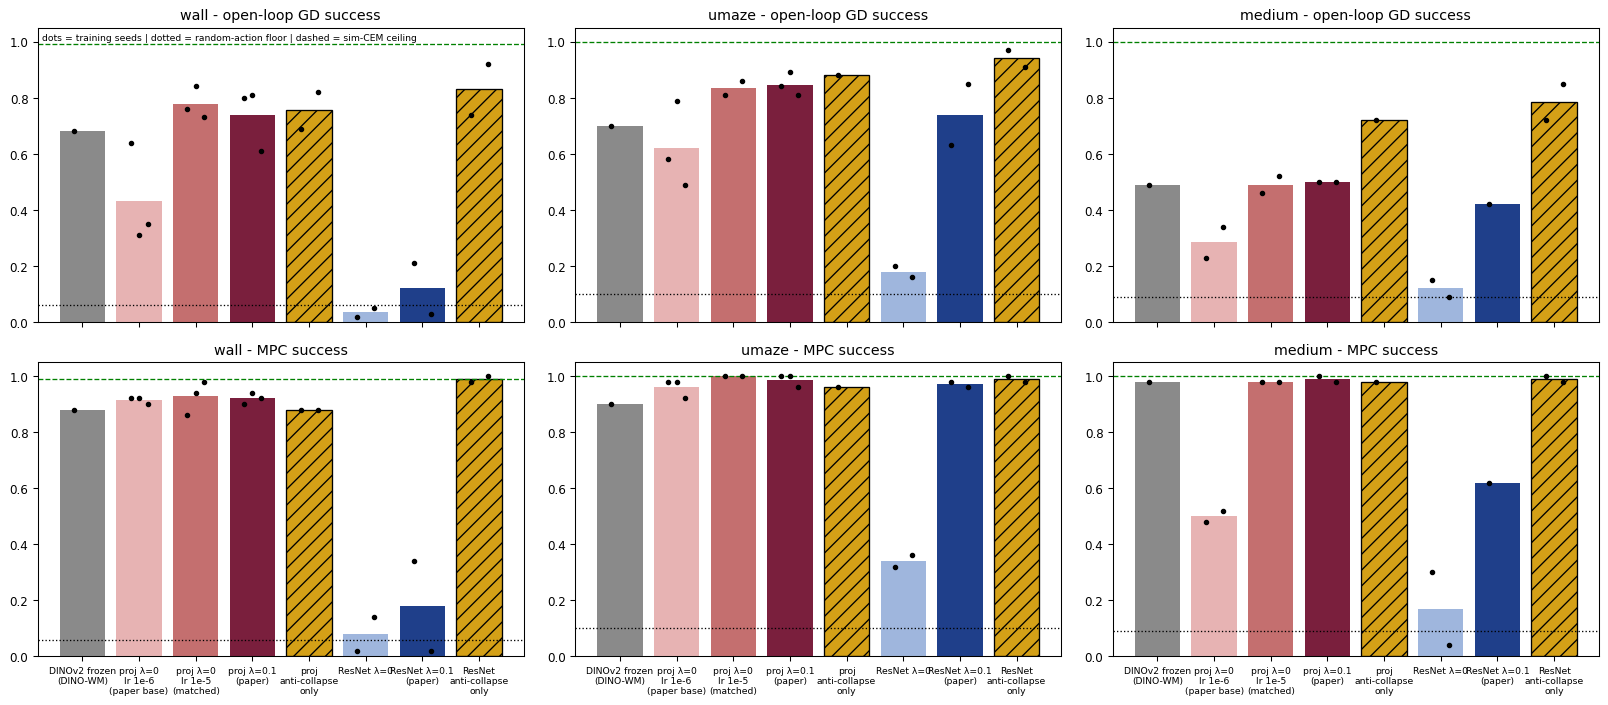

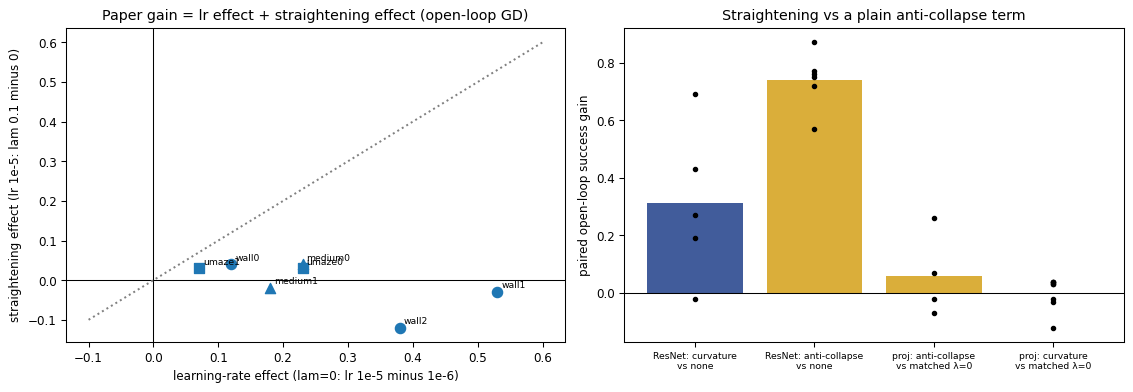

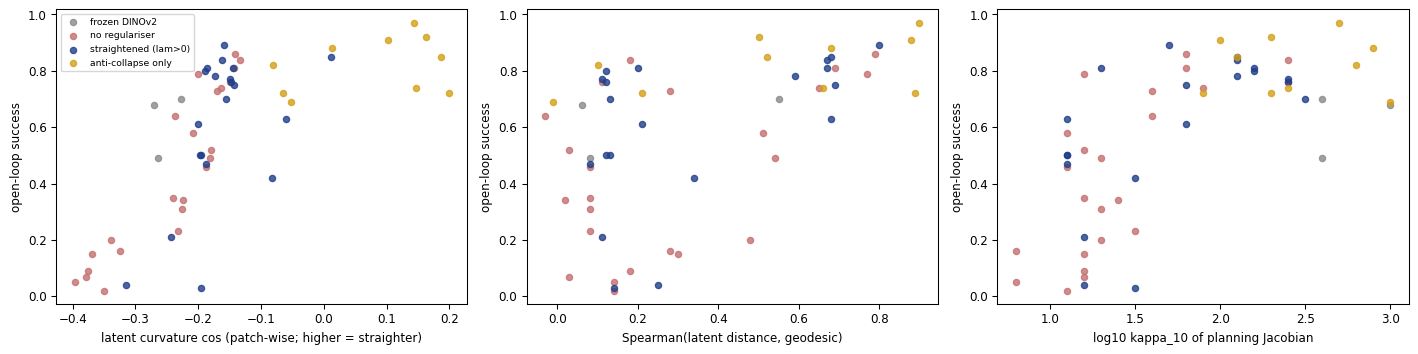

Spearman(curv, OL) over all 56 runs = +0.78
Spearman(rho_geo, OL) over all 56 runs = +0.53
Spearman(logk10, OL) over all 56 runs = +0.65


In [5]:
# FINAL ANALYSIS from the recorded table: paired decomposition (same env, same training seed) + figures.
import numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 95, 'font.size': 9})
def paired(a, b, metric='OL', data=R):
    A = data[data.arm == a].set_index(['env', 'seed'])[metric]; B = data[data.arm == b].set_index(['env', 'seed'])[metric]
    k = A.index.intersection(B.index)
    return (A[k] - B[k]).rename(f'{a} - {b}')
rows = []
for name, a, b in [('paper gain  (proj lam0.1  - proj lam0 lr1e-6)', 'proj lam0.1', 'proj lam0 lr1e-6'),
                   ('lr effect   (proj lam0 lr1e-5 - proj lam0 lr1e-6)', 'proj lam0 lr1e-5', 'proj lam0 lr1e-6'),
                   ('lam effect  (proj lam0.1  - proj lam0 lr1e-5)', 'proj lam0.1', 'proj lam0 lr1e-5'),
                   ('anti-collapse vs lam (proj var-only - proj lam0.1)', 'proj var-only', 'proj lam0.1'),
                   ('ResNet lam effect (ResNet lam0.1 - ResNet lam0)', 'ResNet lam0.1', 'ResNet lam0 lr1e-5'),
                   ('ResNet anti-collapse vs lam (var-only - lam0.1)', 'ResNet var-only', 'ResNet lam0.1'),
                   ('ResNet anti-collapse vs none (var-only - lam0)', 'ResNet var-only', 'ResNet lam0 lr1e-5')]:
    for metric in ['OL', 'MPC']:
        d = paired(a, b, metric)
        rows.append(dict(comparison=name, metric=metric, n_pairs=len(d), mean=d.mean(), sd=d.std(ddof=1), min=d.min(), max=d.max(),
                         t=d.mean() / (d.std(ddof=1) / np.sqrt(len(d))) if len(d) > 1 and d.std() > 0 else np.nan,
                         pairs=' '.join(f"{e[:2]}{s}:{v:+.2f}" for (e, s), v in d.items())))
dec = pd.DataFrame(rows)
print(dec.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))
print("\nOne success rate over 100 episodes has binomial SE ~0.04; a paired difference ~0.06. |t| > ~2.5 with these n is a real effect.")

# (1) Table-1 analogue with brackets and training-seed dots
ARMS = ['DINO frozen', 'proj lam0 lr1e-6', 'proj lam0 lr1e-5', 'proj lam0.1', 'proj var-only', 'ResNet lam0 lr1e-5', 'ResNet lam0.1', 'ResNet var-only']
LBL = ['DINOv2 frozen\n(DINO-WM)', 'proj λ=0\nlr 1e-6\n(paper base)', 'proj λ=0\nlr 1e-5\n(matched)', 'proj λ=0.1\n(paper)', 'proj\nanti-collapse\nonly', 'ResNet λ=0', 'ResNet λ=0.1\n(paper)', 'ResNet\nanti-collapse\nonly']
COL = ['#8a8a8a', '#e7b3b3', '#c46f6f', '#7a1f3d', '#d4a017', '#9fb6dd', '#1f3f8a', '#d4a017']
fig, axs = plt.subplots(2, 3, figsize=(17, 7.5))
for j, env in enumerate(['wall', 'umaze', 'medium']):
    for i, m in enumerate(['OL', 'MPC']):
        ax = axs[i, j]
        for k, a in enumerate(ARMS):
            v = R[(R.env == env) & (R.arm == a)][m].values
            if len(v):
                ax.bar(k, v.mean(), color=COL[k], edgecolor='k' if 'anti' in LBL[k] else None, hatch='//' if 'anti' in LBL[k] else None)
                ax.scatter(np.full(len(v), k) + np.linspace(-.15, .15, len(v)), v, color='k', s=10, zorder=3)
        ax.axhline(BR[env][1], ls=':', c='k', lw=1); ax.axhline(BR[env][2], ls='--', c='g', lw=1)
        ax.set_ylim(0, 1.05); ax.set_title(f"{env} - {'open-loop GD' if m == 'OL' else 'MPC'} success")
        ax.set_xticks(range(len(ARMS))); ax.set_xticklabels(LBL if i == 1 else [''] * len(ARMS), fontsize=7)
axs[0, 0].text(.01, .98, 'dots = training seeds | dotted = random-action floor | dashed = sim-CEM ceiling', transform=axs[0, 0].transAxes, fontsize=7, va='top')
plt.tight_layout(); plt.show()

# (2) The decomposition: every (env, seed) pair, lr effect vs lambda effect
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
lr_e, la_e = paired('proj lam0 lr1e-5', 'proj lam0 lr1e-6'), paired('proj lam0.1', 'proj lam0 lr1e-5')
k = lr_e.index.intersection(la_e.index)
mk = {'wall': 'o', 'umaze': 's', 'medium': '^'}
for (e, s) in k:
    axs[0].scatter(lr_e[(e, s)], la_e[(e, s)], marker=mk[e], s=60, color='C0')
    axs[0].annotate(f'{e}{s}', (lr_e[(e, s)], la_e[(e, s)]), fontsize=7, xytext=(3, 3), textcoords='offset points')
axs[0].axhline(0, c='k', lw=.8); axs[0].axvline(0, c='k', lw=.8); axs[0].plot([-.1, .6], [-.1, .6], ':', c='gray')
axs[0].set_xlabel('learning-rate effect (lam=0: lr 1e-5 minus 1e-6)'); axs[0].set_ylabel('straightening effect (lr 1e-5: lam 0.1 minus 0)')
axs[0].set_title('Paper gain = lr effect + straightening effect (open-loop GD)')
d1, d2, d3 = paired('ResNet lam0.1', 'ResNet lam0 lr1e-5'), paired('ResNet var-only', 'ResNet lam0 lr1e-5'), paired('proj var-only', 'proj lam0 lr1e-5')
for x, (lab, d) in enumerate([('ResNet: curvature\nvs none', d1), ('ResNet: anti-collapse\nvs none', d2), ('proj: anti-collapse\nvs lam=0 lr1e-5', d3),
                              ('proj: curvature\nvs lam=0 lr1e-5', la_e)]):
    axs[1].bar(x, d.mean(), color=['#1f3f8a', '#d4a017', '#d4a017', '#7a1f3d'][x], alpha=.85)
    axs[1].scatter(np.full(len(d), x), d.values, c='k', s=10, zorder=3)
    axs[1].set_xticks(range(4)); axs[1].set_xticklabels(['ResNet: curvature\nvs none', 'ResNet: anti-collapse\nvs none', 'proj: anti-collapse\nvs matched λ=0', 'proj: curvature\nvs matched λ=0'], fontsize=7)
axs[1].axhline(0, c='k', lw=.8); axs[1].set_ylabel('paired open-loop success gain'); axs[1].set_title('Straightening vs a plain anti-collapse term')
plt.tight_layout(); plt.show()

# (3) Does the paper's mechanism predict success? (Fig. 5-right / Fig. 6 / Thm 4.4 as numbers, all runs)
fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
fam = lambda a: 'anti-collapse only' if 'var' in a else ('straightened (lam>0)' if ('lam0.' in a or 'lam1e' in a) and 'lam0 ' not in a else ('frozen DINOv2' if 'DINO' in a else 'no regulariser'))
for f_, c_ in [('frozen DINOv2', '#8a8a8a'), ('no regulariser', '#c46f6f'), ('straightened (lam>0)', '#1f3f8a'), ('anti-collapse only', '#d4a017')]:
    d = R[R.arm.map(fam) == f_]
    for ax, x in zip(axs, ['curv', 'rho_geo', 'logk10']):
        ax.scatter(d[x], d.OL, c=c_, label=f_, s=22, alpha=.8)
for ax, x in zip(axs, ['latent curvature cos (patch-wise; higher = straighter)', 'Spearman(latent distance, geodesic)', 'log10 kappa_10 of planning Jacobian']):
    ax.set_xlabel(x); ax.set_ylabel('open-loop success')
axs[0].legend(fontsize=7); plt.tight_layout(); plt.show()
for x in ['curv', 'rho_geo', 'logk10']:
    print(f"Spearman({x}, OL) over all {len(R)} runs = {R[[x, 'OL']].corr('spearman').iloc[0, 1]:+.2f}")